# # 20. Batch PPO Trading - SRL Evaluation
En este notebook entrenamos y evaluamos agentes de Reinforcement Learning (DQN) 
utilizando las representaciones de estado extraídas mediante AE, CPC y Transformer.

In [1]:
import pandas as pd
import numpy as np
import os
import random
import torch
import json
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
from stable_baselines3 import PPO,DQN
from stable_baselines3.common.vec_env import DummyVecEnv


# Configuración de rutas
import sys
sys.path.append('../')
from src.trading_env_improved  import SRLTradingEnv  # Importamos tu entorno modular
from sklearn.preprocessing import MinMaxScaler
from src.SRLTradingEnv_v2 import SRLTradingEnv_v2

# ## 1. Configuración Global y Reproducibilidad

In [2]:
N_SEEDS = 5
SEEDS = [42,123,456,789,1011]
TIMEFRAME = '1h'
#'baseline','temporal-ae', 'cpc', 'transformer', 
MODELS_TO_TEST = ['baseline','temporal-ae', 'cpc', 'transformer', 'combinado'] # Los 3 que hemos creado + el baseline
# Fecha para separar Train y Validación (ajusta según tu dataset)
FROM_SAFE = '2021-12-31_00-00-00'
UNTIL_SAFE = '2025-07-31_00-00-00'
TRAIN_END_DATE = '2024-12-31'

INITIAL_BALANCE = 1000
FEE = 0.001 # 0.1% comisión (Binance Standard)

# Crear carpetas de salida
os.makedirs('../RL_outputs/results', exist_ok=True)
os.makedirs('../RL_outputs/models', exist_ok=True)

# ## 2. Funciones de Soporte

In [3]:
def load_data_all_types(model_type, tf):
    price_path = f'../data/01-output-BTCUSDT_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-log-return.csv'
    df_prices_full = pd.read_csv(price_path, index_col='date', parse_dates=True)
    
    if model_type == 'baseline':
        path = f'../data/02-baseline-BTCUSDT_{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}-technical-indicators.csv'
        df_feat = pd.read_csv(path, index_col='date', parse_dates=True)
    
    elif model_type == 'combinado':
        # Cargamos los tres y los unimos
        paths = {
            'ae': f'../data/02-srl-temporal-ae-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'cpc': f'../data/02-srl-cpc-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv',
            'trans': f'../data/02-srl-transformer-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        }
        df_ae = pd.read_csv(paths['ae'], index_col='date', parse_dates=True)
        df_cpc = pd.read_csv(paths['cpc'], index_col='date', parse_dates=True)
        df_trans = pd.read_csv(paths['trans'], index_col='date', parse_dates=True)
        
        # El join asegura que solo se usen las fechas que están en los tres (alineación total)
        df_feat = df_ae.join(df_cpc, how='inner').join(df_trans, how='inner')
        
    else:
        emb_path = f'../data/02-srl-{model_type}-{tf}-from-{FROM_SAFE}-until-{UNTIL_SAFE}.csv'
        df_feat = pd.read_csv(emb_path, index_col='date', parse_dates=True)
    
    # Limpieza y sincronización con precios
    cols_to_drop = ['open', 'high', 'low', 'close', 'volume', 'tradecount']
    df_feat = df_feat.drop(columns=[c for c in cols_to_drop if c in df_feat.columns])
    df_feat = df_feat.select_dtypes(include=[np.number])

    # Sincronizamos con la columna 'close' del original
    combined = df_feat.join(df_prices_full[['close']], how='inner')
    
    prices = combined['close']
    features = combined.drop(columns=['close'])
    
    return features, prices

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo detectado: {device}")
if torch.cuda.is_available():
    print(f"Ferrari detectado: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ ATENCIÓN: Sigues en el bus (CPU).")

Dispositivo detectado: cuda
Ferrari detectado: NVIDIA GeForce RTX 4060 Laptop GPU


# ## 3. Bucle Principal de Entrenamiento y Comparativa

In [5]:
batch_results = []

for model_name in MODELS_TO_TEST:
    print(f"\n" + "="*50)
    print(f" EVALUANDO MODELO: {model_name.upper()} ")
    print("="*50)
    
    try:
        df_feat, df_prices = load_data_all_types(model_name, TIMEFRAME)
    except FileNotFoundError as e:
        print(f"Error: No se encontró el archivo para {model_name}. Saltando...")
        continue

    # Escalado para Baseline
    if model_name == 'baseline':
        scaler = MinMaxScaler()
        train_mask = df_feat.index <= TRAIN_END_DATE
        df_feat.iloc[train_mask] = scaler.fit_transform(df_feat.iloc[train_mask])
        df_feat.iloc[~train_mask] = scaler.transform(df_feat.iloc[~train_mask])
    
    # Split temporal
    df_feat_train = df_feat[df_feat.index <= TRAIN_END_DATE]
    df_prices_train = df_prices[df_prices.index <= TRAIN_END_DATE]
    
    df_feat_val = df_feat[df_feat.index > TRAIN_END_DATE]
    df_prices_val = df_prices[df_prices.index > TRAIN_END_DATE]
    
    print(f"Dataset: {len(df_feat_train)} pasos entrenamiento | {len(df_feat_val)} pasos validación")

    for seed in SEEDS:
        print(f"> Semilla {seed}...")
        set_seed(seed)
        
        # 1. Entorno de ENTRENAMIENTO (v2 con Shorting)
        train_env = DummyVecEnv([lambda: SRLTradingEnv_v2(
            df_feat_train, 
            df_prices_train, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE
        )])
        
        # 2. Agente PPO
        agent = PPO(
            "MlpPolicy",
            train_env,
            learning_rate=3e-5,
            n_steps=2048,
            batch_size=64,
            gamma=0.99,
            verbose=0,
            seed=seed
        )
        
        # 3. Entrenamiento
        total_steps = len(df_feat_train) * 20
        agent.learn(total_timesteps=total_steps)
        
        # 4. Entorno de VALIDACIÓN (!!! DEBE SER v2 TAMBIÉN !!!)
        val_env = SRLTradingEnv_v2(
            df_feat_val, 
            df_prices_val, 
            initial_balance=INITIAL_BALANCE, 
            fee=FEE
        )
        
        obs, _ = val_env.reset()
        done = False
        history = []

        while not done:
            # Deterministic=True para evaluar la estrategia pura
            action, _ = agent.predict(obs, deterministic=True)
            obs, reward, done, _, info = val_env.step(action)
            history.append(info['net_worth'])
        
        final_nw = history[-1]
        total_return = (final_nw - INITIAL_BALANCE) / INITIAL_BALANCE
        
        print(f"   [Semilla {seed}] Retorno Final: {total_return*100:.2f}%")
        
        batch_results.append({
            'srl_model': model_name,
            'seed': seed,
            'final_net_worth': final_nw,
            'total_return': total_return,
            'equity_curve': history
        })
        
        # Guardar con nombre PPO para evitar dramas
        agent.save(f"../RL_outputs/models/ppo_{model_name}_seed_{seed}")


 EVALUANDO MODELO: BASELINE 
Dataset: 26278 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno Final: 0.00%
> Semilla 123...
   [Semilla 123] Retorno Final: 0.00%
> Semilla 456...
   [Semilla 456] Retorno Final: 0.00%
> Semilla 789...
   [Semilla 789] Retorno Final: 0.00%
> Semilla 1011...
   [Semilla 1011] Retorno Final: 26.40%

 EVALUANDO MODELO: TEMPORAL-AE 
Dataset: 26135 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno Final: 25.38%
> Semilla 123...
   [Semilla 123] Retorno Final: 25.38%
> Semilla 456...
   [Semilla 456] Retorno Final: 11.64%
> Semilla 789...
   [Semilla 789] Retorno Final: 0.00%
> Semilla 1011...
   [Semilla 1011] Retorno Final: 13.38%

 EVALUANDO MODELO: CPC 
Dataset: 26127 pasos entrenamiento | 4698 pasos validación
> Semilla 42...
   [Semilla 42] Retorno Final: -3.11%
> Semilla 123...
   [Semilla 123] Retorno Final: 23.76%
> Semilla 456...
   [Semilla 456] Retorno Final: -0.29%
> Semilla 789.

# ## 4. Resumen de Resultados y Comparativa

In [6]:
df_results = pd.DataFrame(batch_results)
summary = df_results.groupby('srl_model')['total_return'].agg(['mean', 'std', 'max']).reset_index()

print("\n" + "#"*50)
print(" COMPARATIVA FINAL DE RENDIMIENTO ")
print("#"*50)
print(summary)

df_results.to_csv('../RL_outputs/results/DQN_SRL_Comparison_Summary.csv', index=False)


##################################################
 COMPARATIVA FINAL DE RENDIMIENTO 
##################################################
     srl_model      mean       std       max
0     baseline  0.052809  0.118084  0.264043
1    combinado  0.021675  0.083554  0.165836
2          cpc  0.007431  0.135601  0.237610
3  temporal-ae  0.151561  0.106563  0.253788
4  transformer  0.101515  0.139005  0.253788


In [7]:
# 1. Calcular el retorno del Bitcoin (Buy & Hold) en el periodo de validación
price_start = df_prices_val.iloc[0]
price_end = df_prices_val.iloc[-1]
bh_return = (price_end - price_start) / price_start

# 2. Agrupar resultados de la IA (Media de todas las semillas)
ia_summary = df_results.groupby('srl_model')['total_return'].mean().reset_index()
ia_summary.columns = ['Modelo', 'Retorno_IA']

# 3. Calcular el "Alpha" (Exceso de retorno sobre el mercado)
ia_summary['Buy_Hold_BTC'] = bh_return
ia_summary['Alpha'] = ia_summary['Retorno_IA'] - ia_summary['Buy_Hold_BTC']

# 4. Formatear para lectura fácil
ia_summary['Retorno_IA'] = ia_summary['Retorno_IA'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Buy_Hold_BTC'] = ia_summary['Buy_Hold_BTC'].map(lambda x: f"{x*100:.2f}%")
ia_summary['Alpha'] = ia_summary['Alpha'].map(lambda x: f"{x*100:.2f}%")

print("="*60)
print(f" BENCHMARK: {TRAIN_END_DATE} hasta Final ")
print("="*60)
print(f"Precio inicial BTC: ${price_start:,.2f}")
print(f"Precio final BTC:   ${price_end:,.2f}")
print(f"RETORNO MERCADO:    {bh_return*100:.2f}%")
print("-"*60)
print(ia_summary)
print("="*60)

# Verificación de "Outperformance"
best_model = df_results.groupby('srl_model')['total_return'].mean().idxmax()
best_return = df_results.groupby('srl_model')['total_return'].mean().max()

if best_return > bh_return:
    print(f"🚀 ¡ÉXITO! El modelo {best_model.upper()} ha batido al mercado.")
else:
    print(f"⚖️ El mercado ha sido más fuerte. El modelo {best_model.upper()} ha sido más conservador.")

 BENCHMARK: 2024-12-31 hasta Final 
Precio inicial BTC: $92,435.57
Precio final BTC:   $115,764.08
RETORNO MERCADO:    25.24%
------------------------------------------------------------
        Modelo Retorno_IA Buy_Hold_BTC    Alpha
0     baseline      5.28%       25.24%  -19.96%
1    combinado      2.17%       25.24%  -23.07%
2          cpc      0.74%       25.24%  -24.49%
3  temporal-ae     15.16%       25.24%  -10.08%
4  transformer     10.15%       25.24%  -15.09%
⚖️ El mercado ha sido más fuerte. El modelo TEMPORAL-AE ha sido más conservador.



 ANALIZANDO MODELO: BASELINE | SEMILLA: 42
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


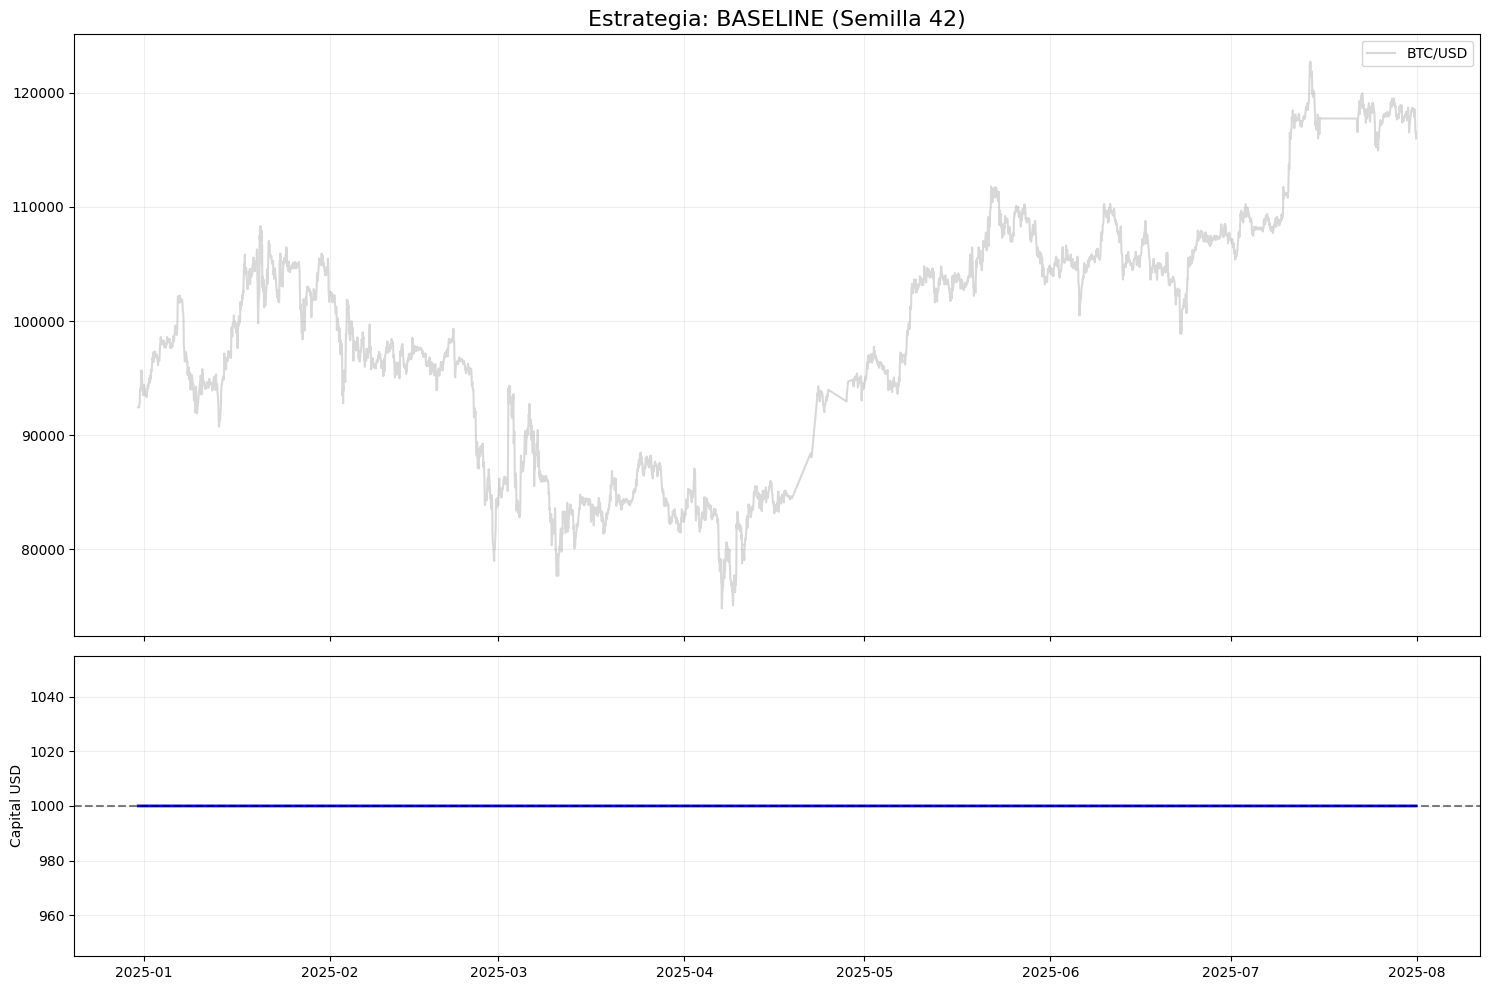


 ANALIZANDO MODELO: BASELINE | SEMILLA: 123
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


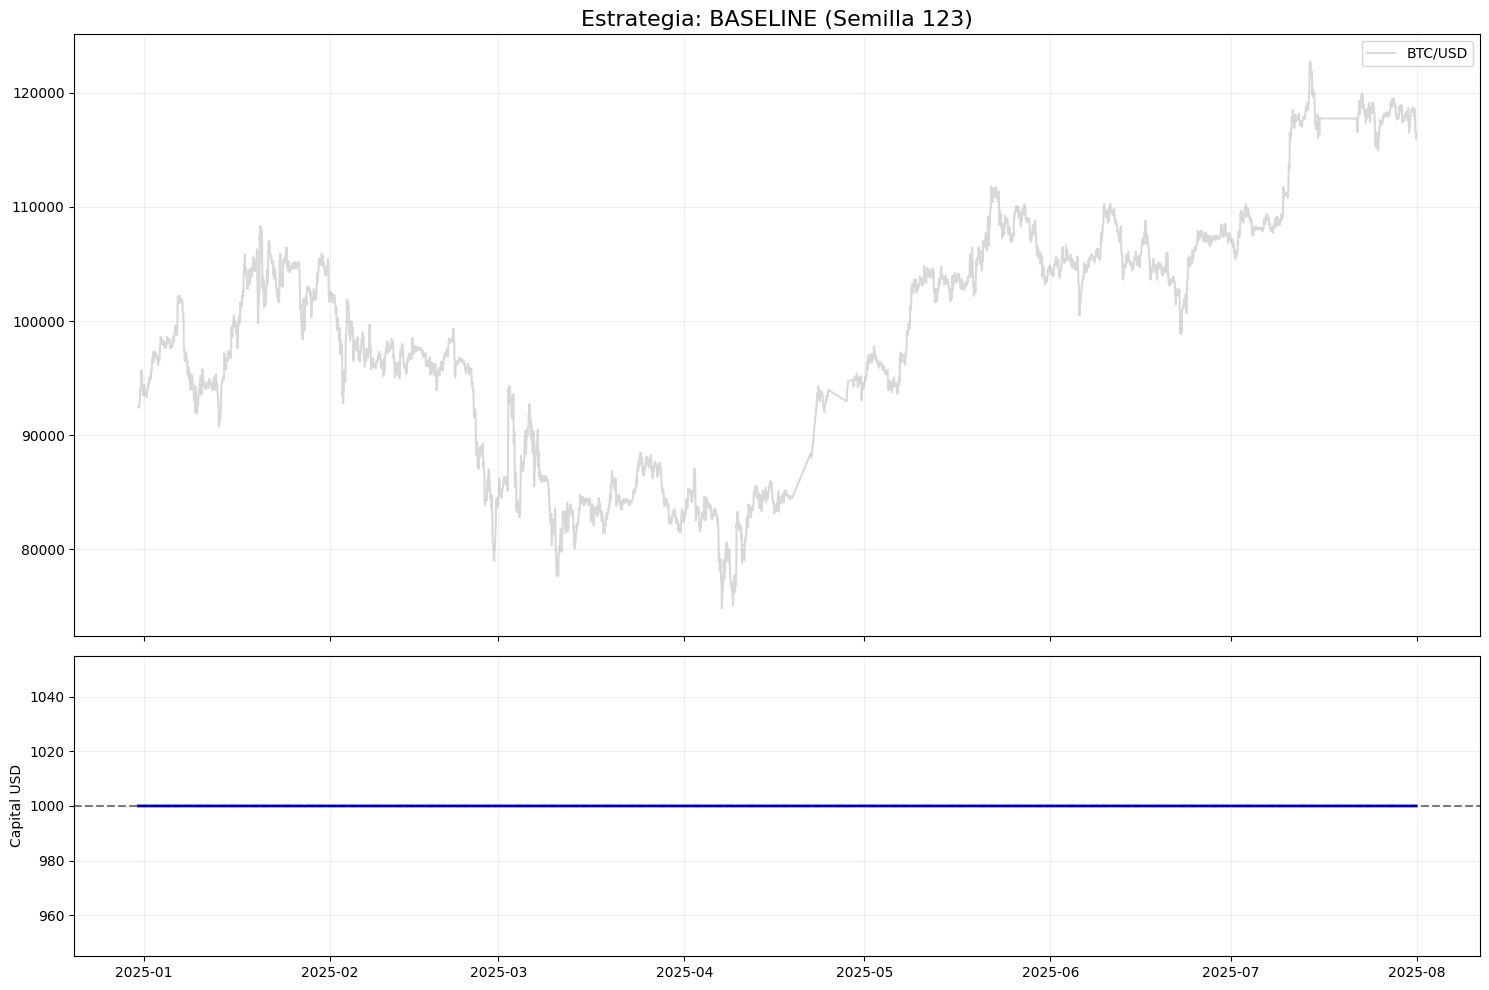


 ANALIZANDO MODELO: BASELINE | SEMILLA: 456
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


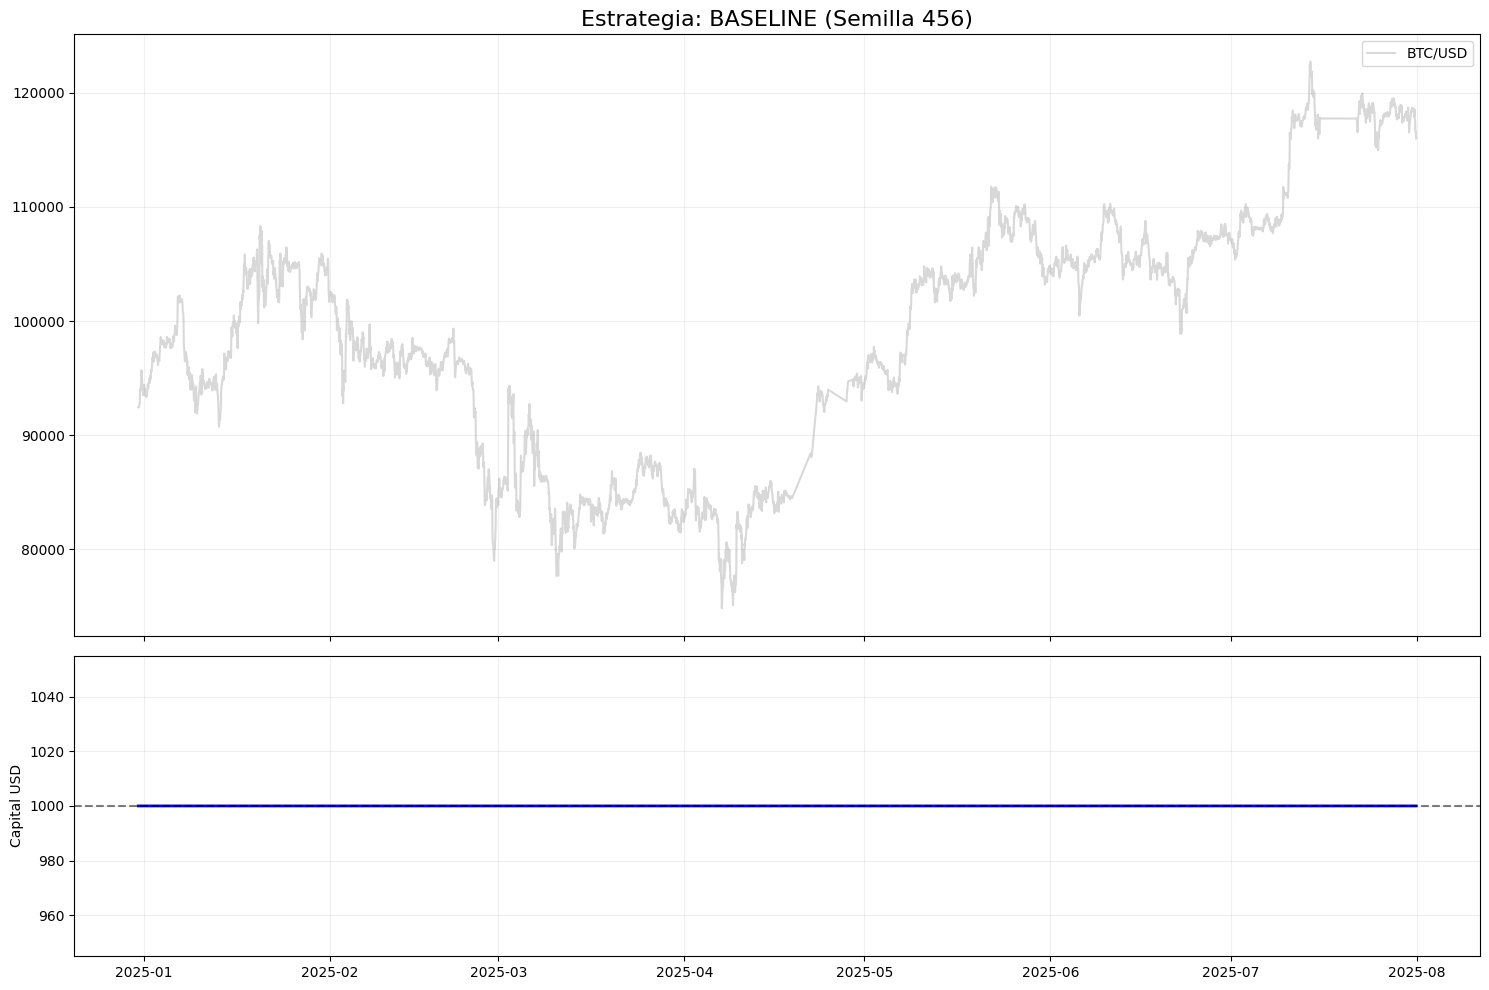


 ANALIZANDO MODELO: BASELINE | SEMILLA: 789
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


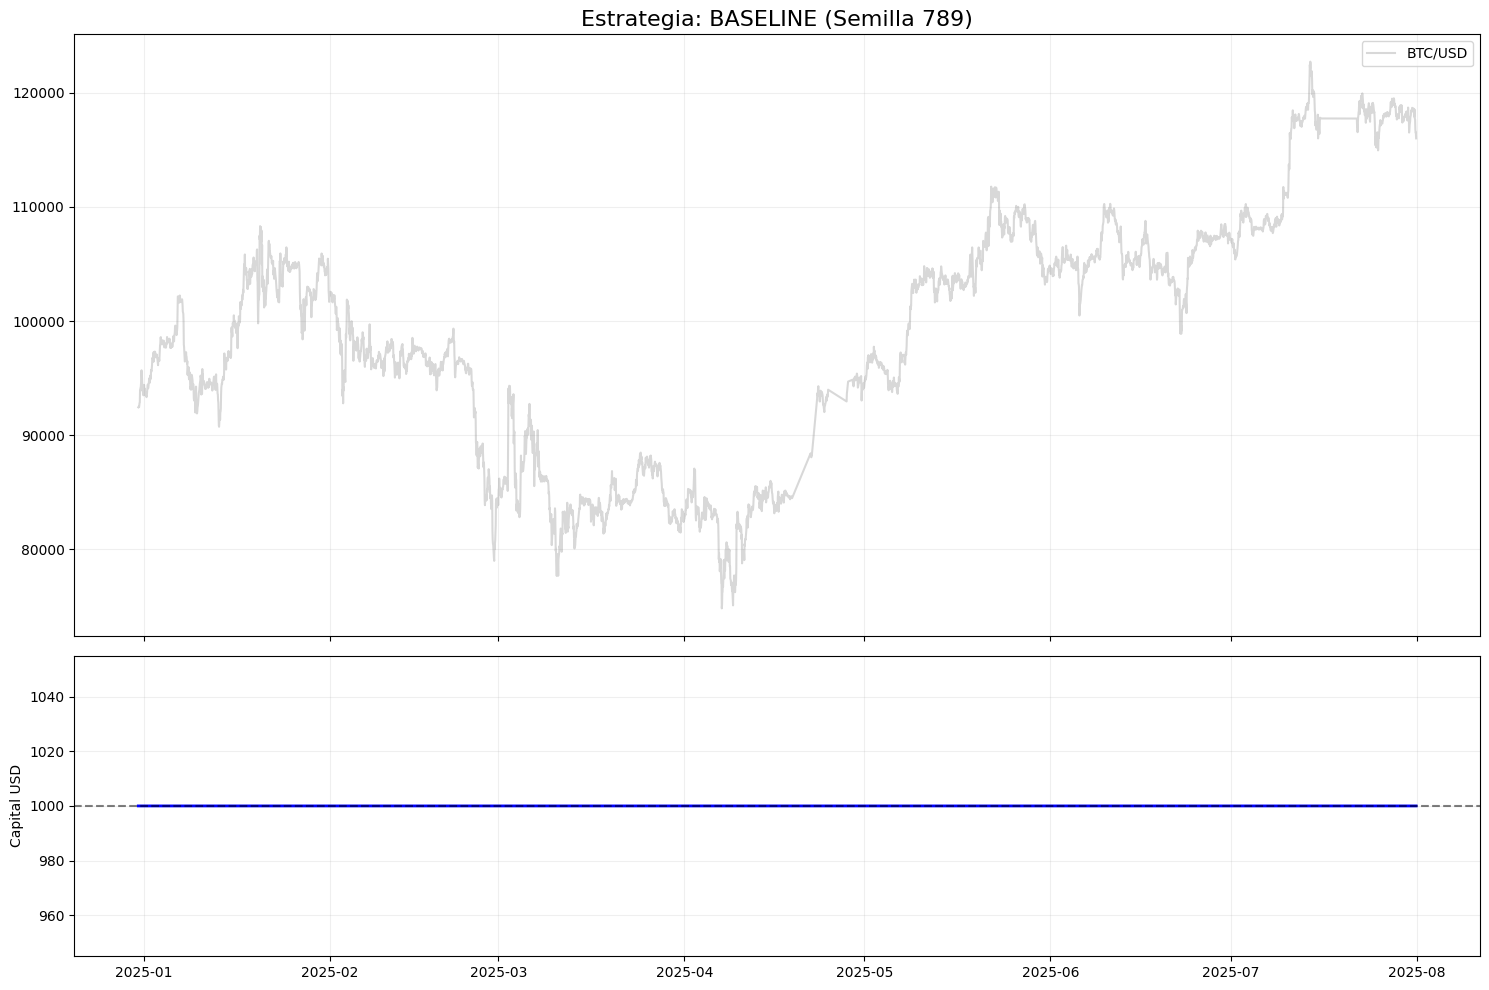


 ANALIZANDO MODELO: BASELINE | SEMILLA: 1011
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 12 | 🔴 Ventas: 11
📊 Total Operaciones: 23
🏁 Balance Final: $1264.04 | 📈 Retorno: 26.40%
----------------------------------


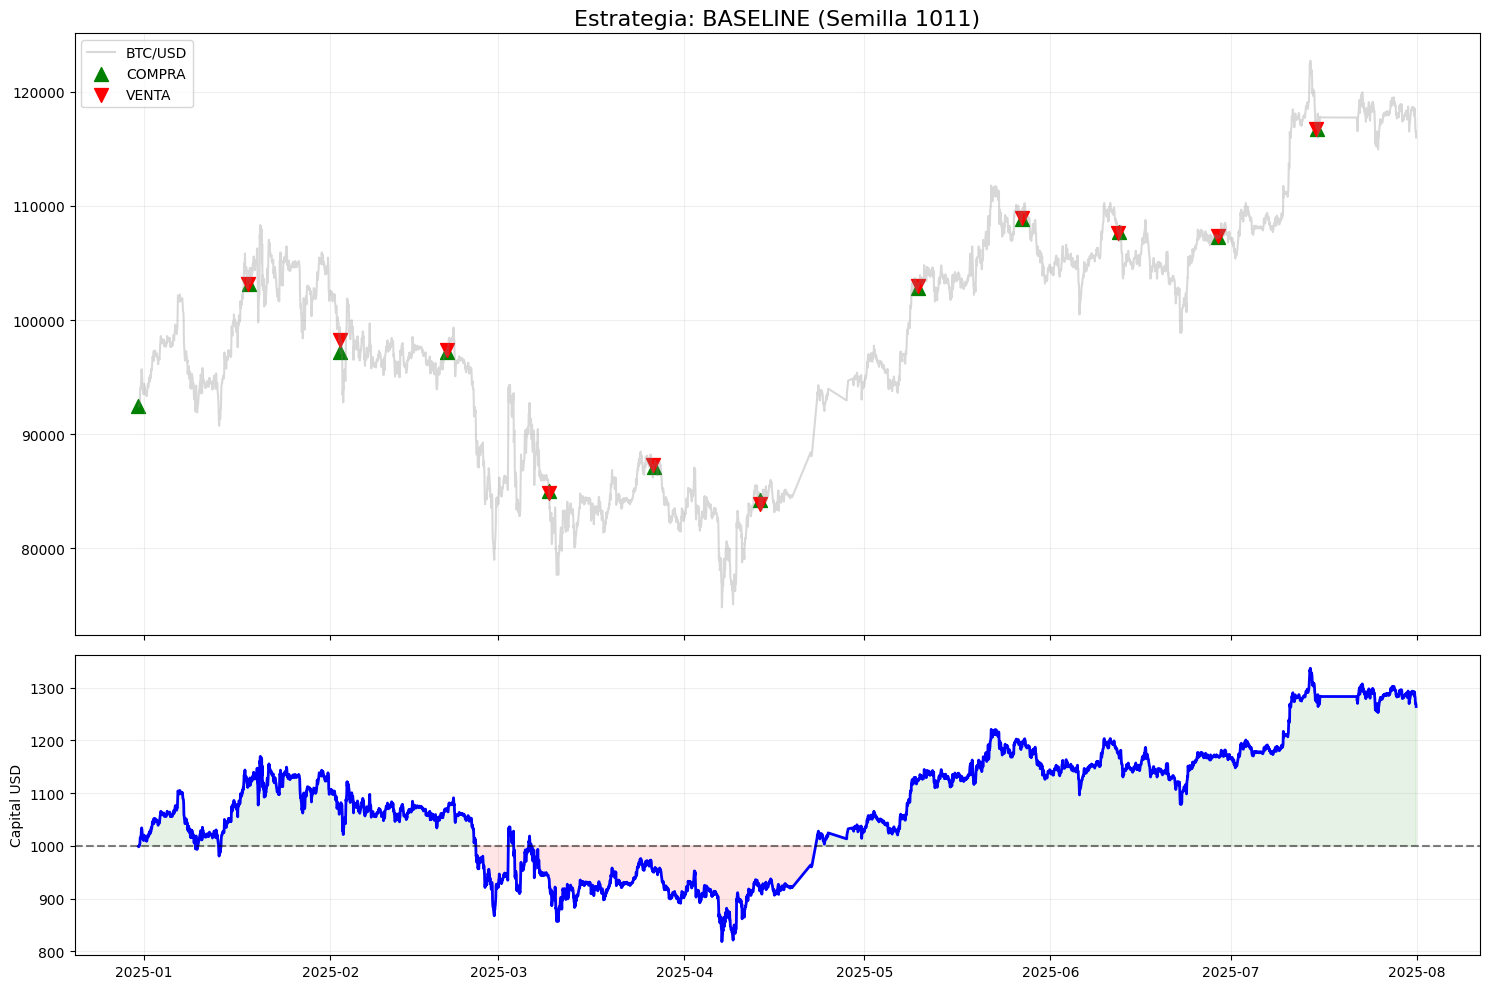


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 1 | 🔴 Ventas: 0
📊 Total Operaciones: 1
🏁 Balance Final: $1253.79 | 📈 Retorno: 25.38%
----------------------------------


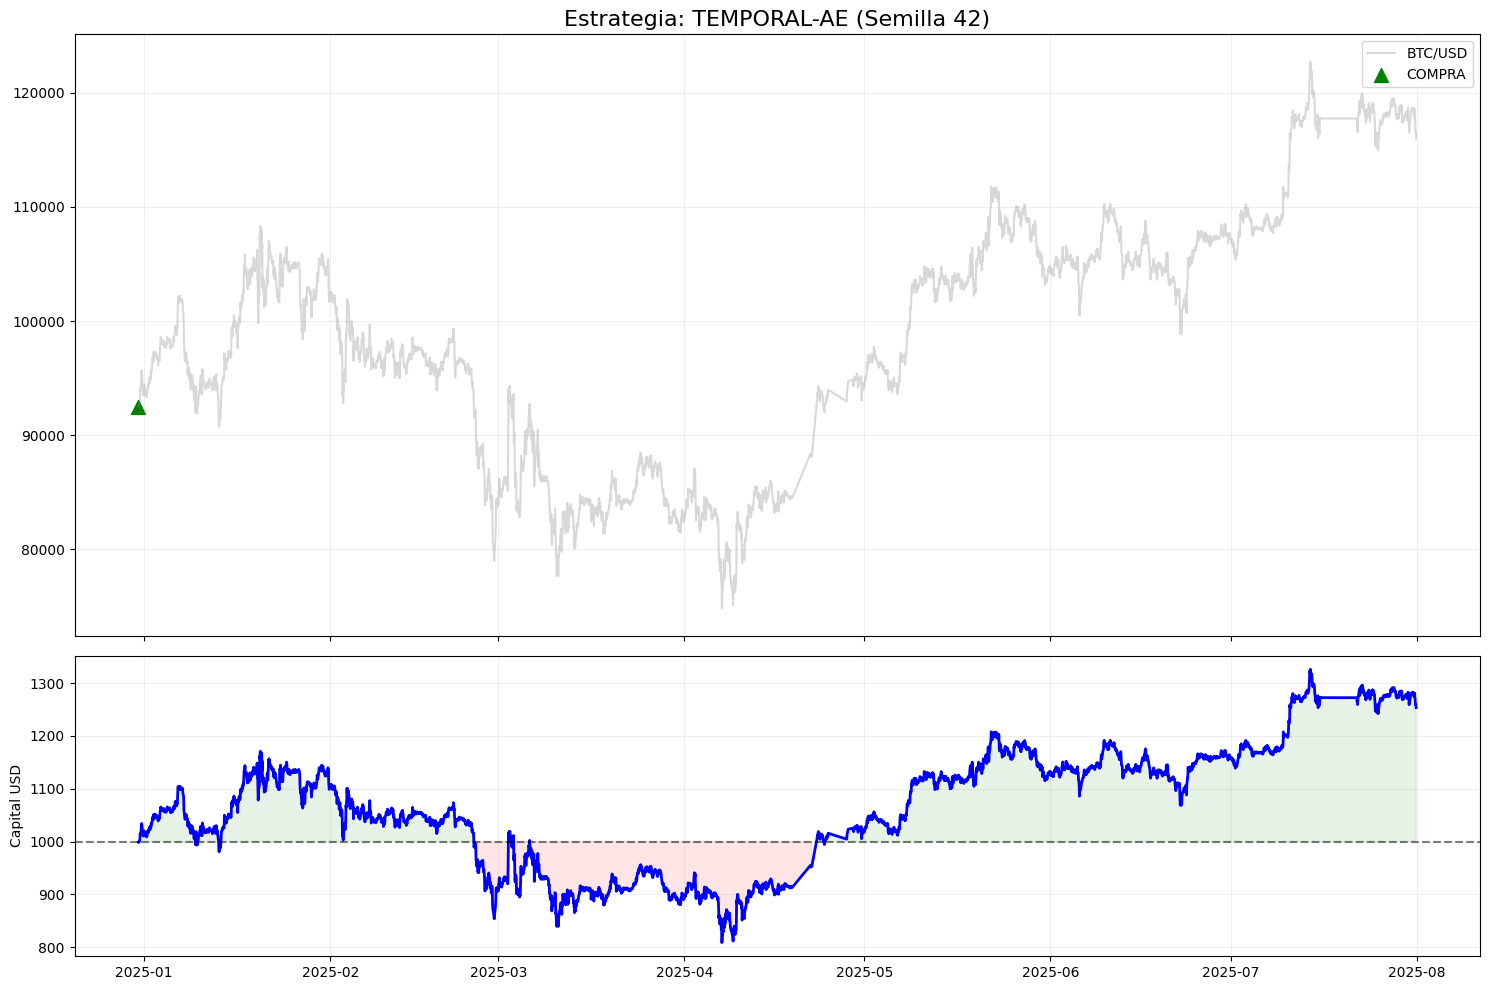


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 1 | 🔴 Ventas: 0
📊 Total Operaciones: 1
🏁 Balance Final: $1253.79 | 📈 Retorno: 25.38%
----------------------------------


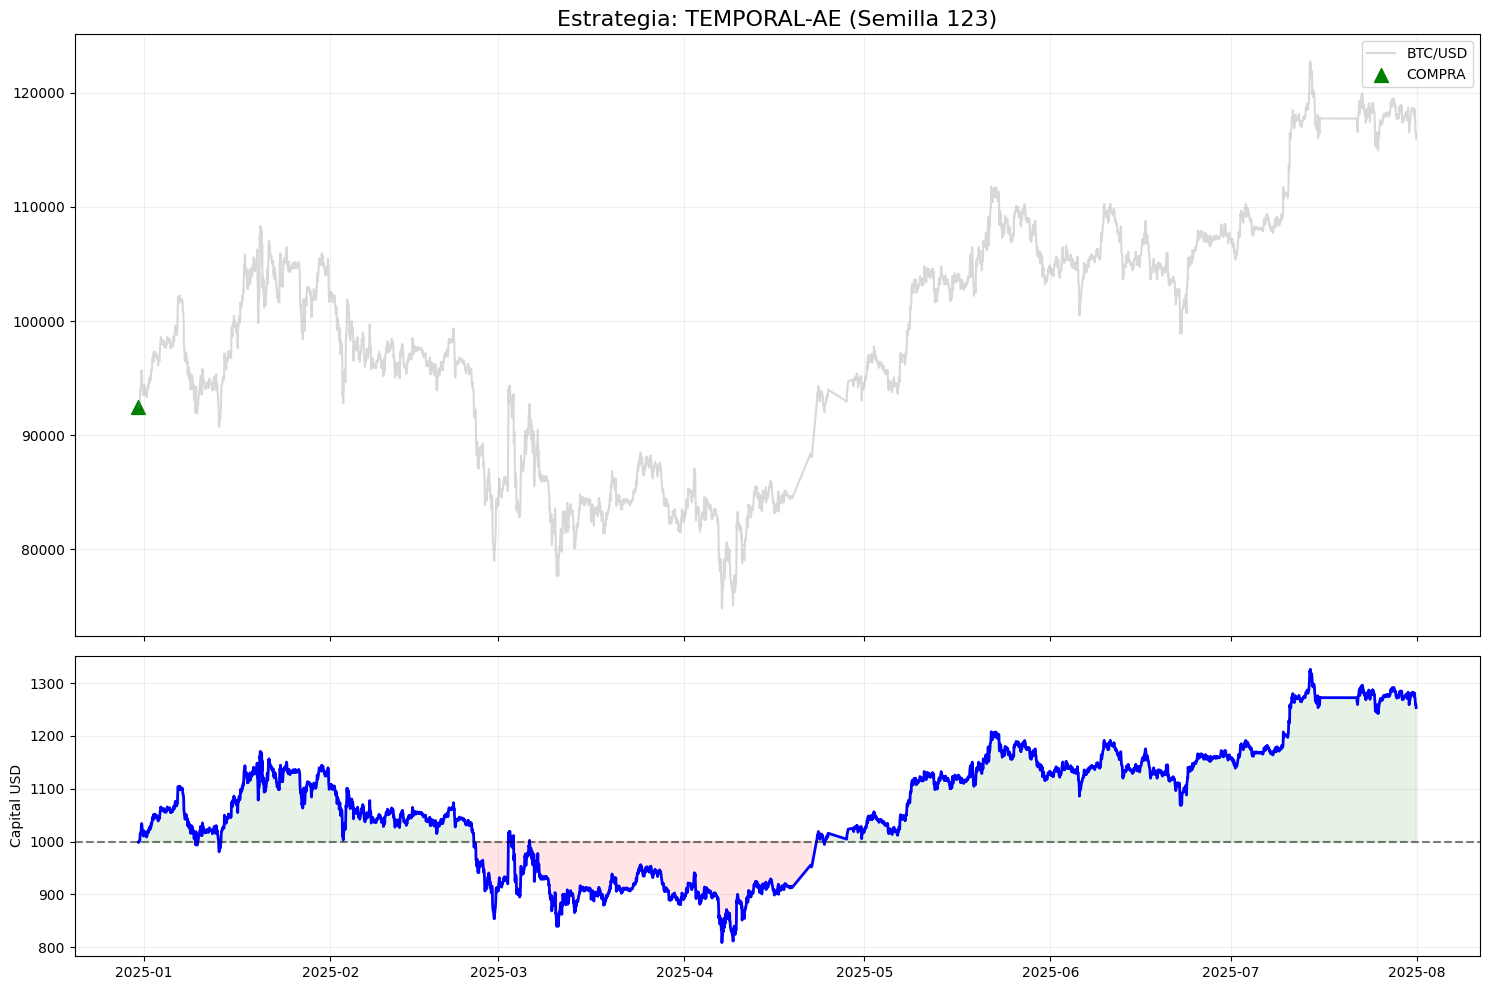


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 7 | 🔴 Ventas: 7
📊 Total Operaciones: 14
🏁 Balance Final: $1116.38 | 📈 Retorno: 11.64%
----------------------------------


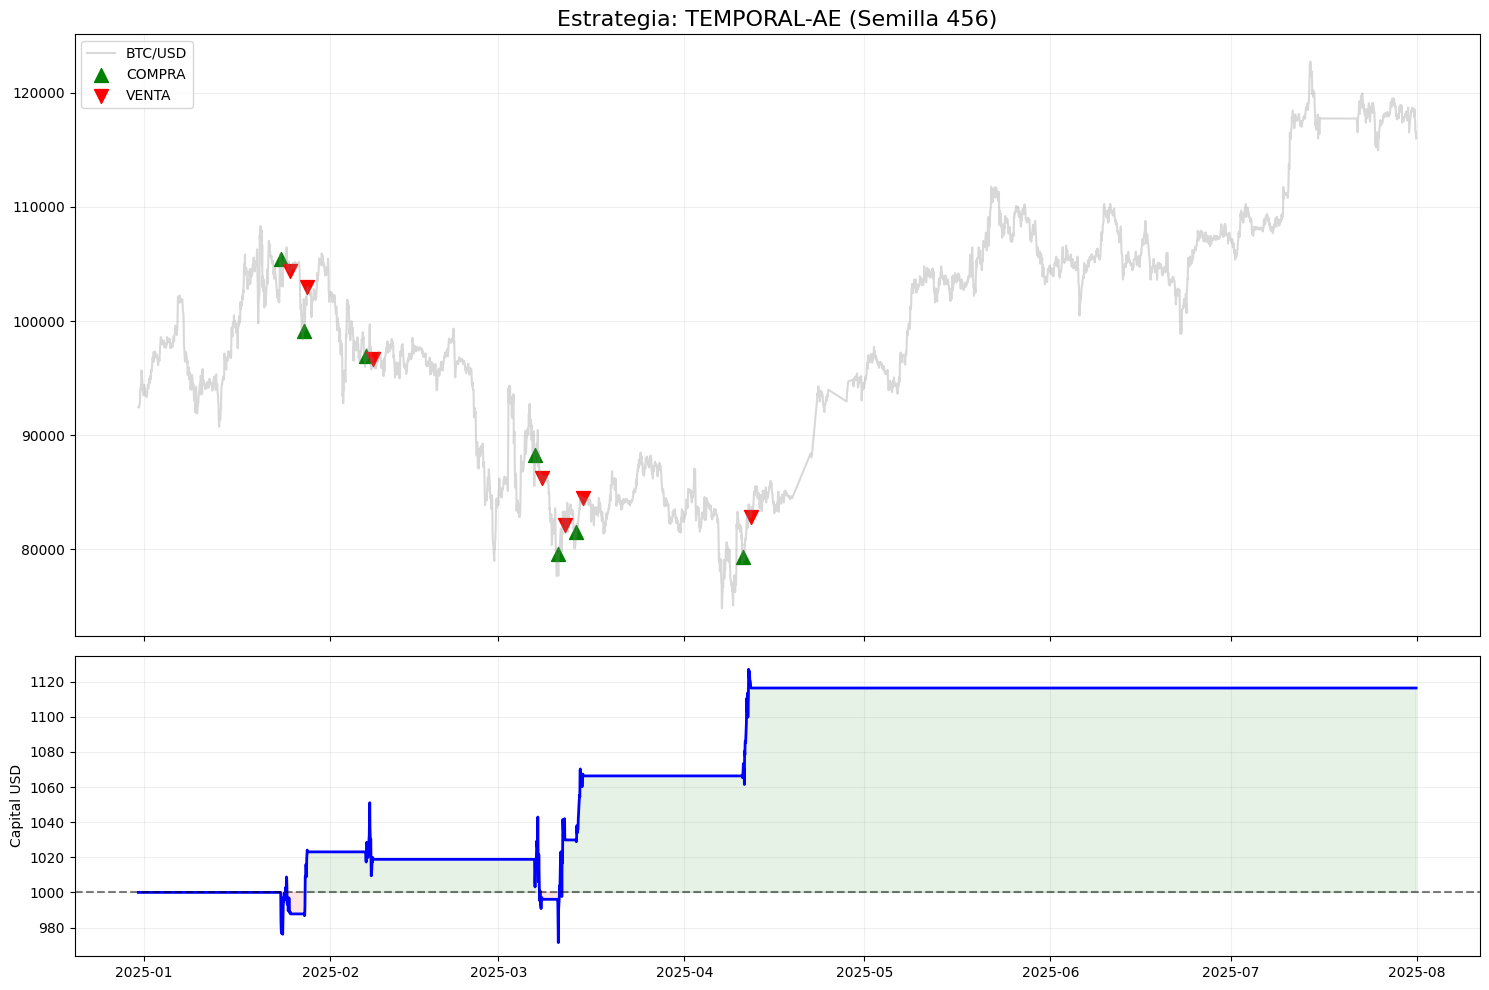


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 789
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


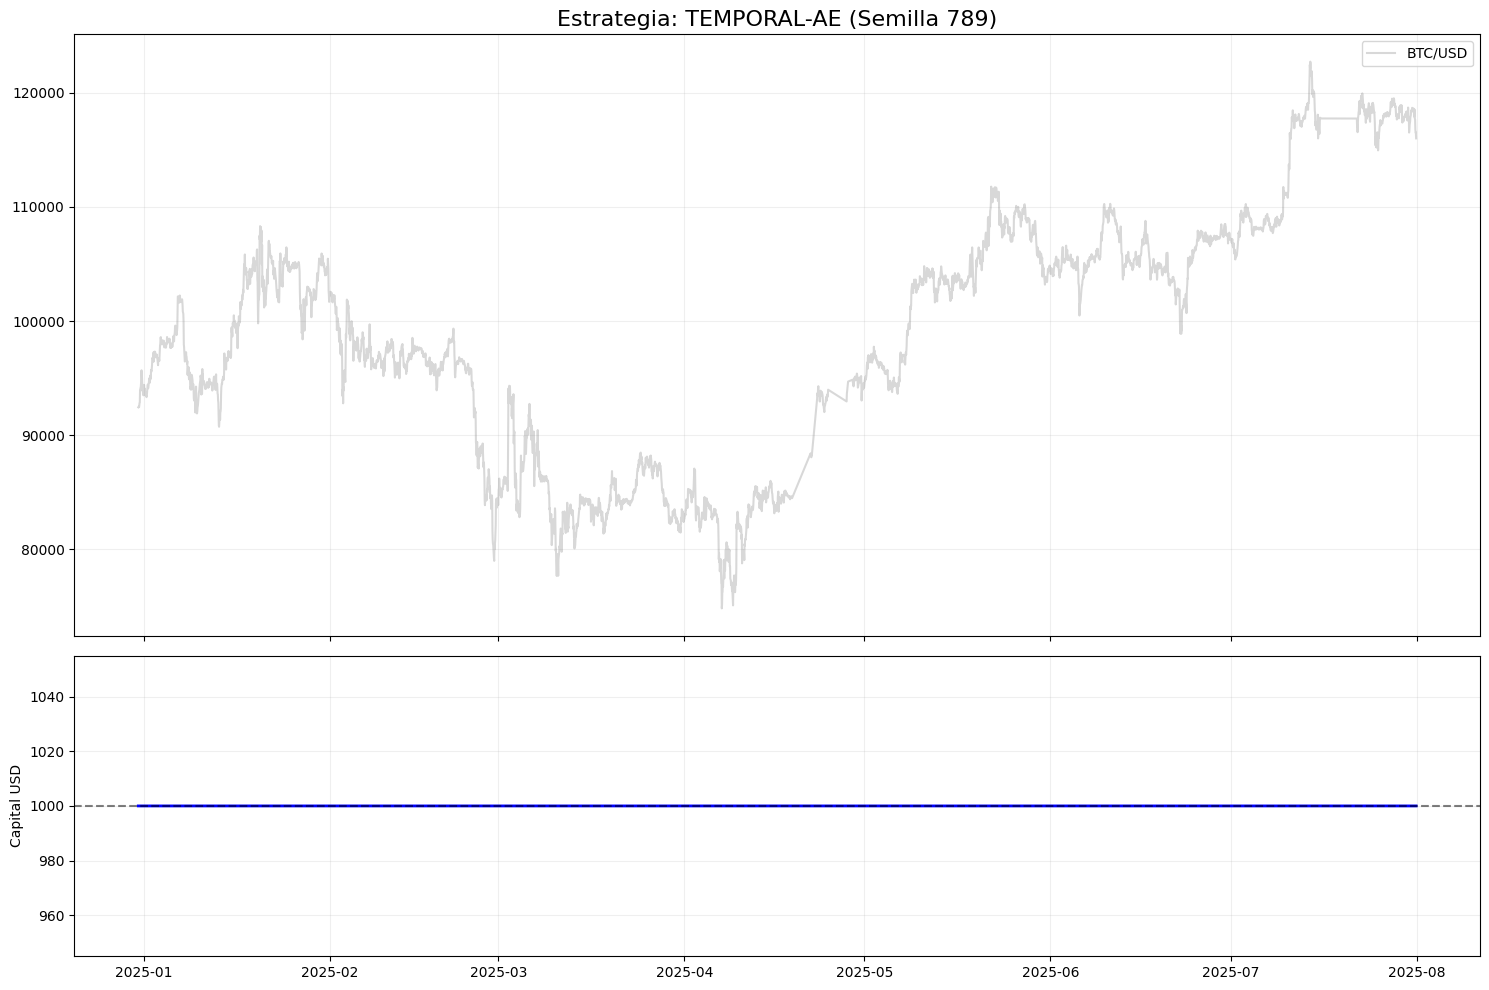


 ANALIZANDO MODELO: TEMPORAL-AE | SEMILLA: 1011
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 18 | 🔴 Ventas: 44
📊 Total Operaciones: 62
🏁 Balance Final: $1133.84 | 📈 Retorno: 13.38%
----------------------------------


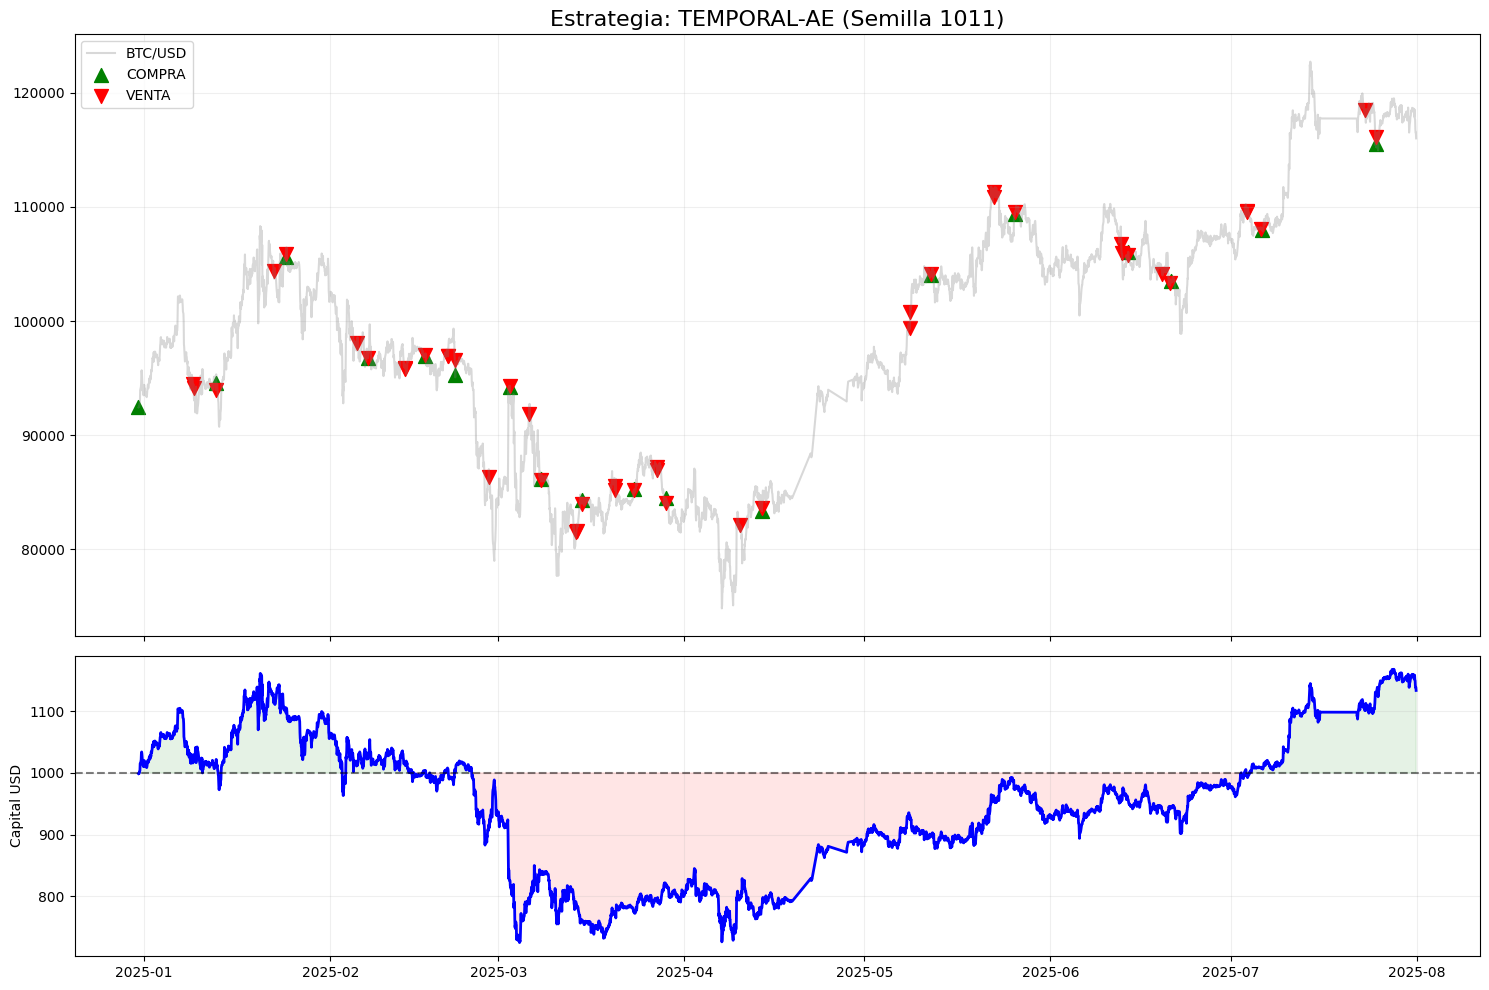


 ANALIZANDO MODELO: CPC | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 136 | 🔴 Ventas: 222
📊 Total Operaciones: 358
🏁 Balance Final: $968.89 | 📈 Retorno: -3.11%
----------------------------------


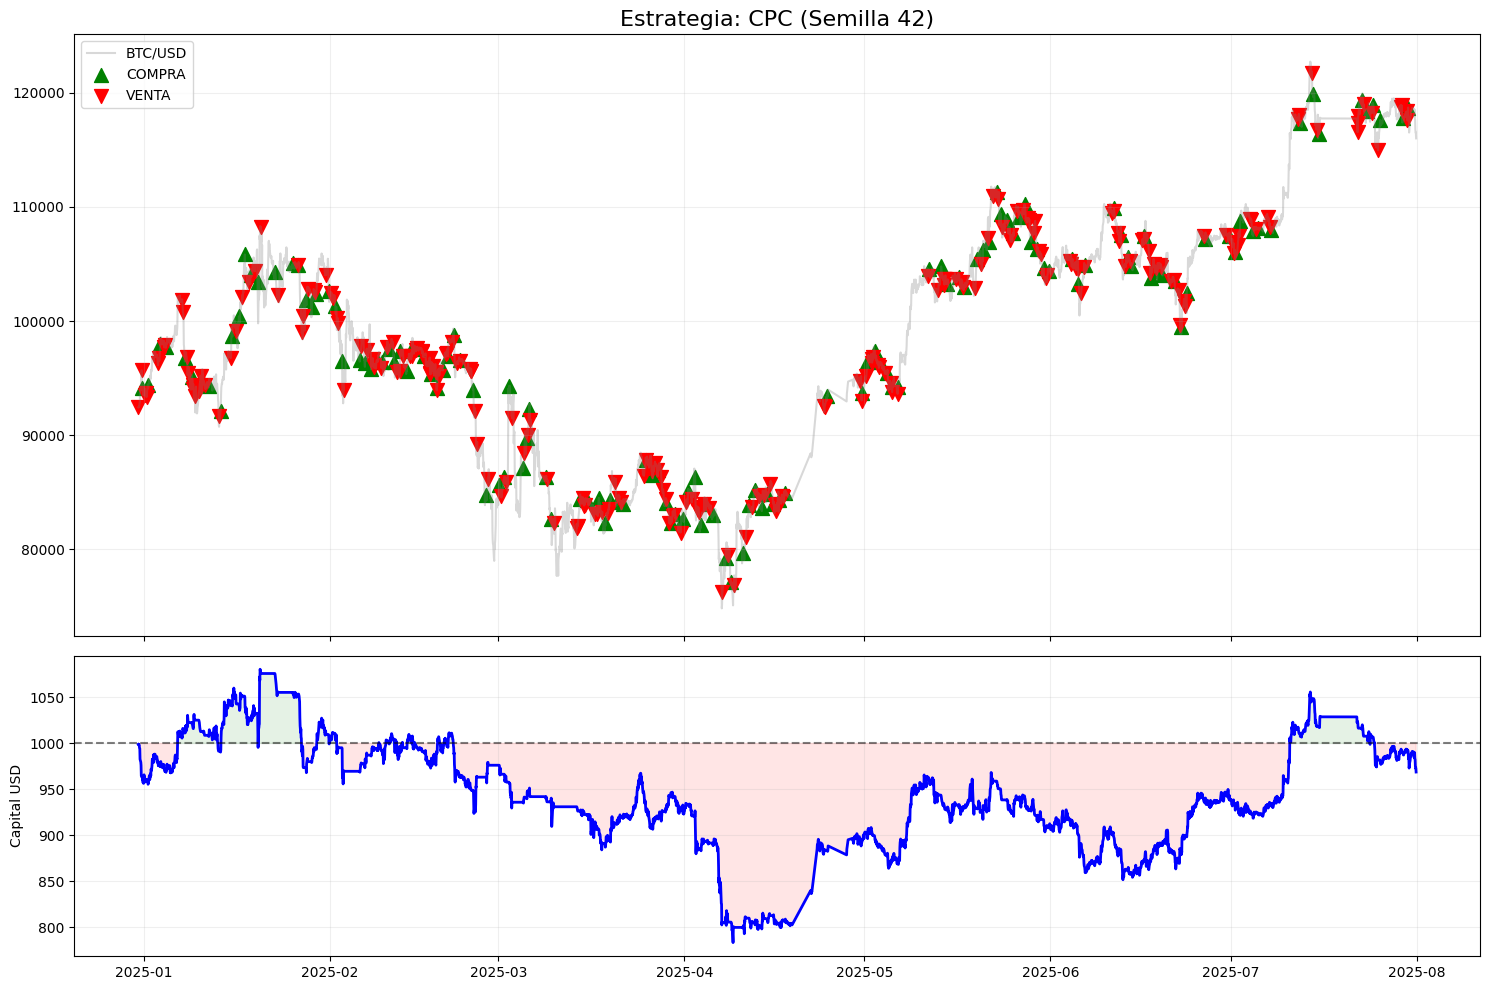


 ANALIZANDO MODELO: CPC | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 96 | 🔴 Ventas: 165
📊 Total Operaciones: 261
🏁 Balance Final: $1237.61 | 📈 Retorno: 23.76%
----------------------------------


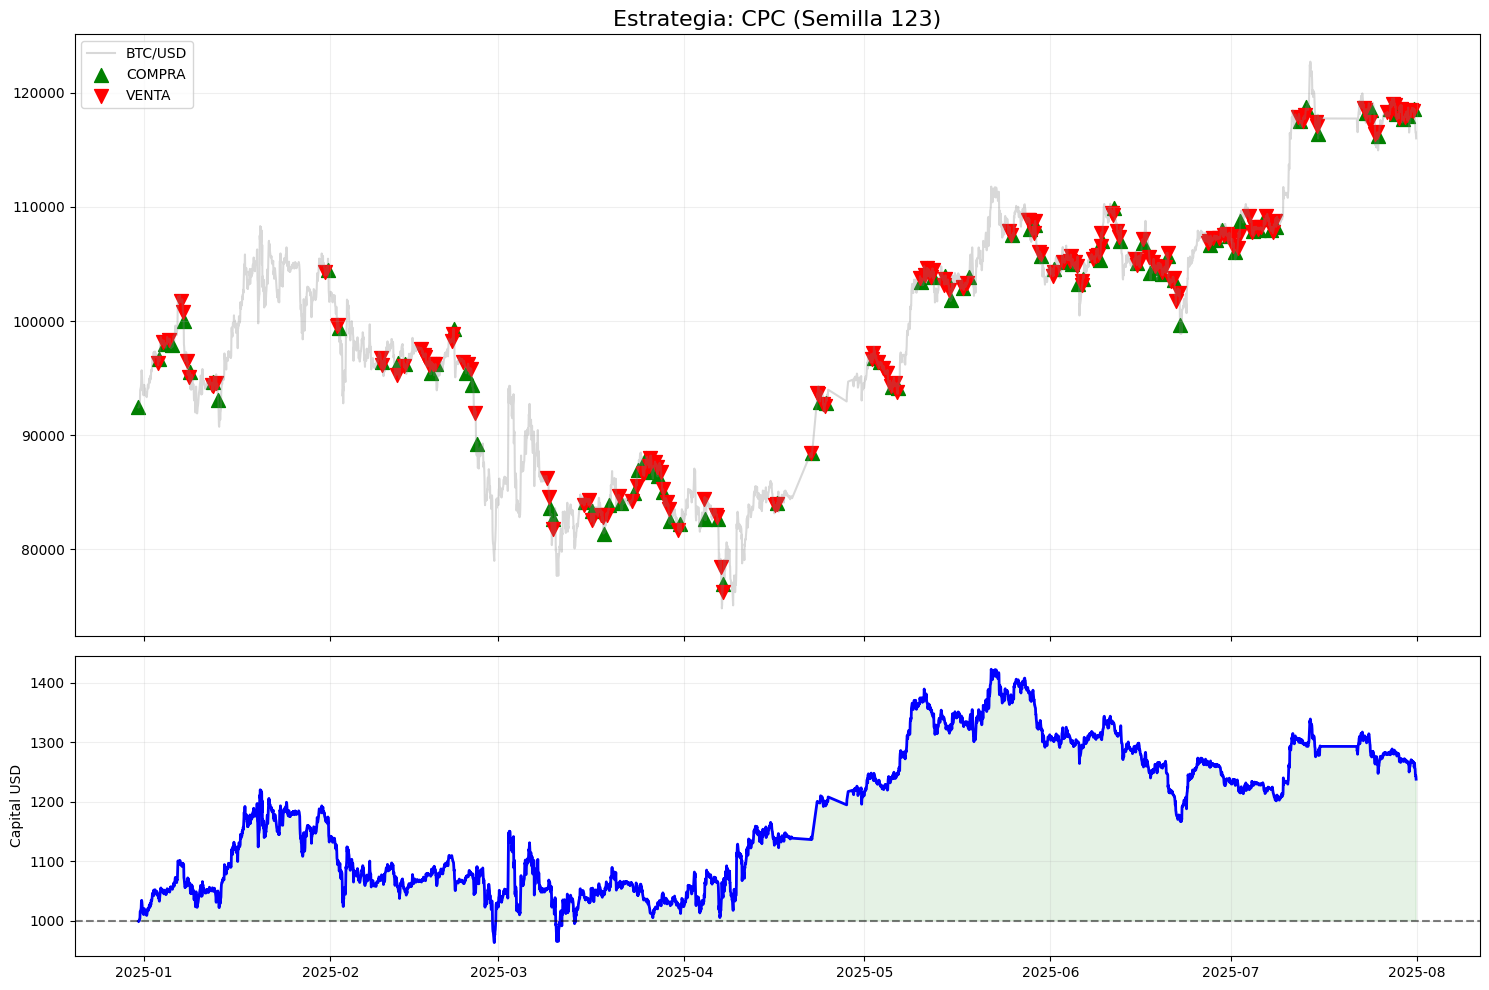


 ANALIZANDO MODELO: CPC | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 30
📊 Total Operaciones: 30
🏁 Balance Final: $997.08 | 📈 Retorno: -0.29%
----------------------------------


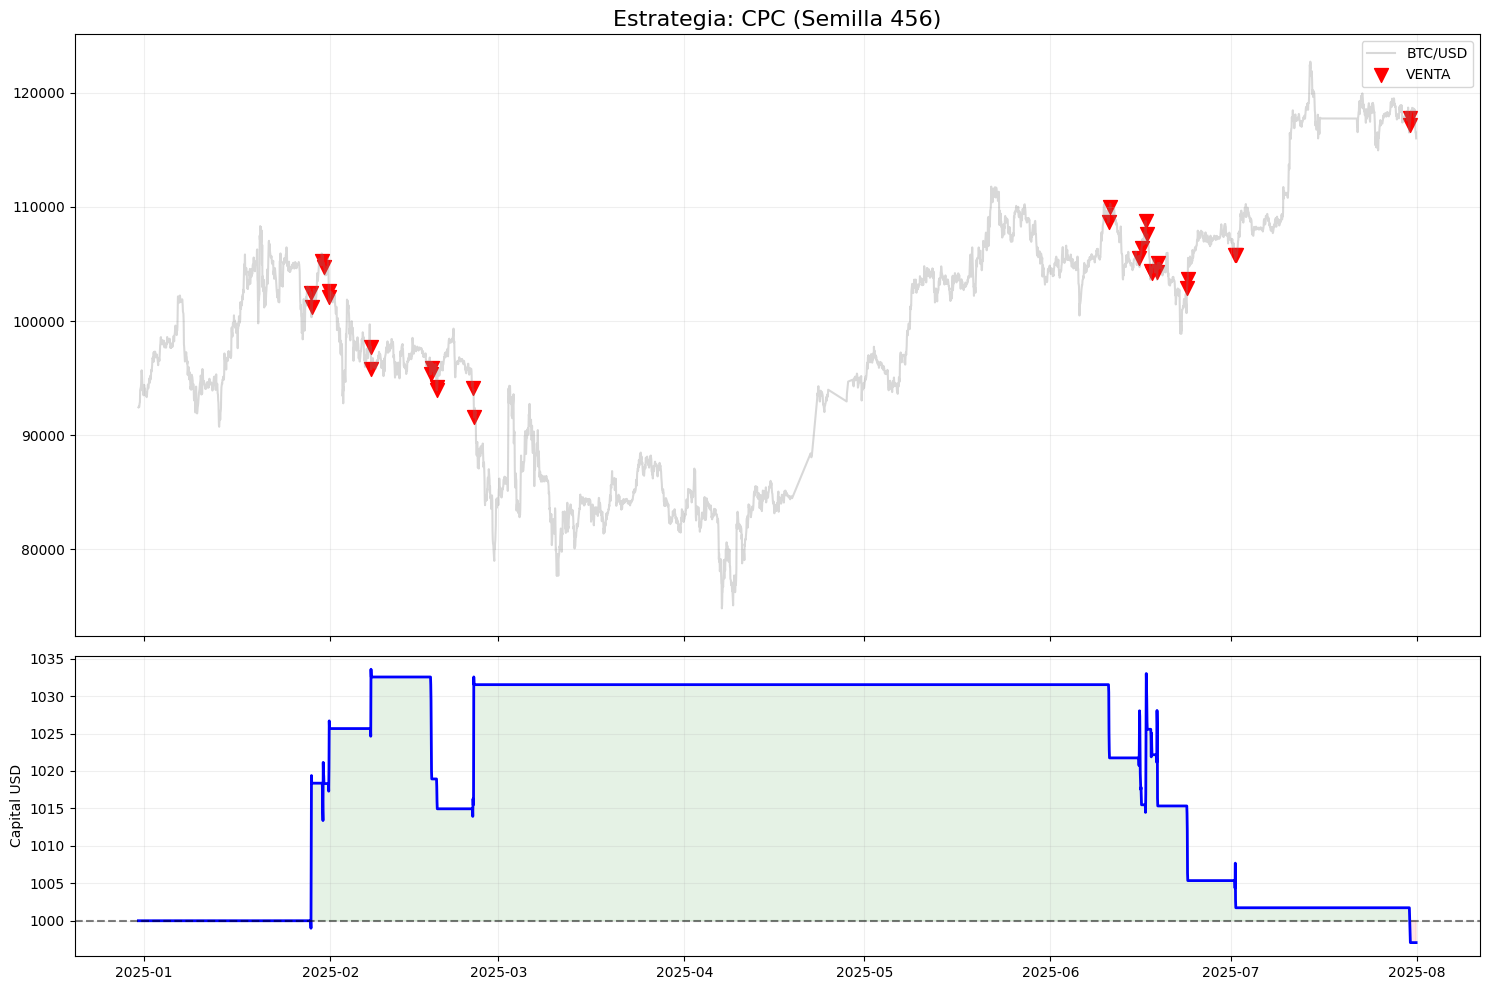


 ANALIZANDO MODELO: CPC | SEMILLA: 789
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 95 | 🔴 Ventas: 282
📊 Total Operaciones: 377
🏁 Balance Final: $881.13 | 📈 Retorno: -11.89%
----------------------------------


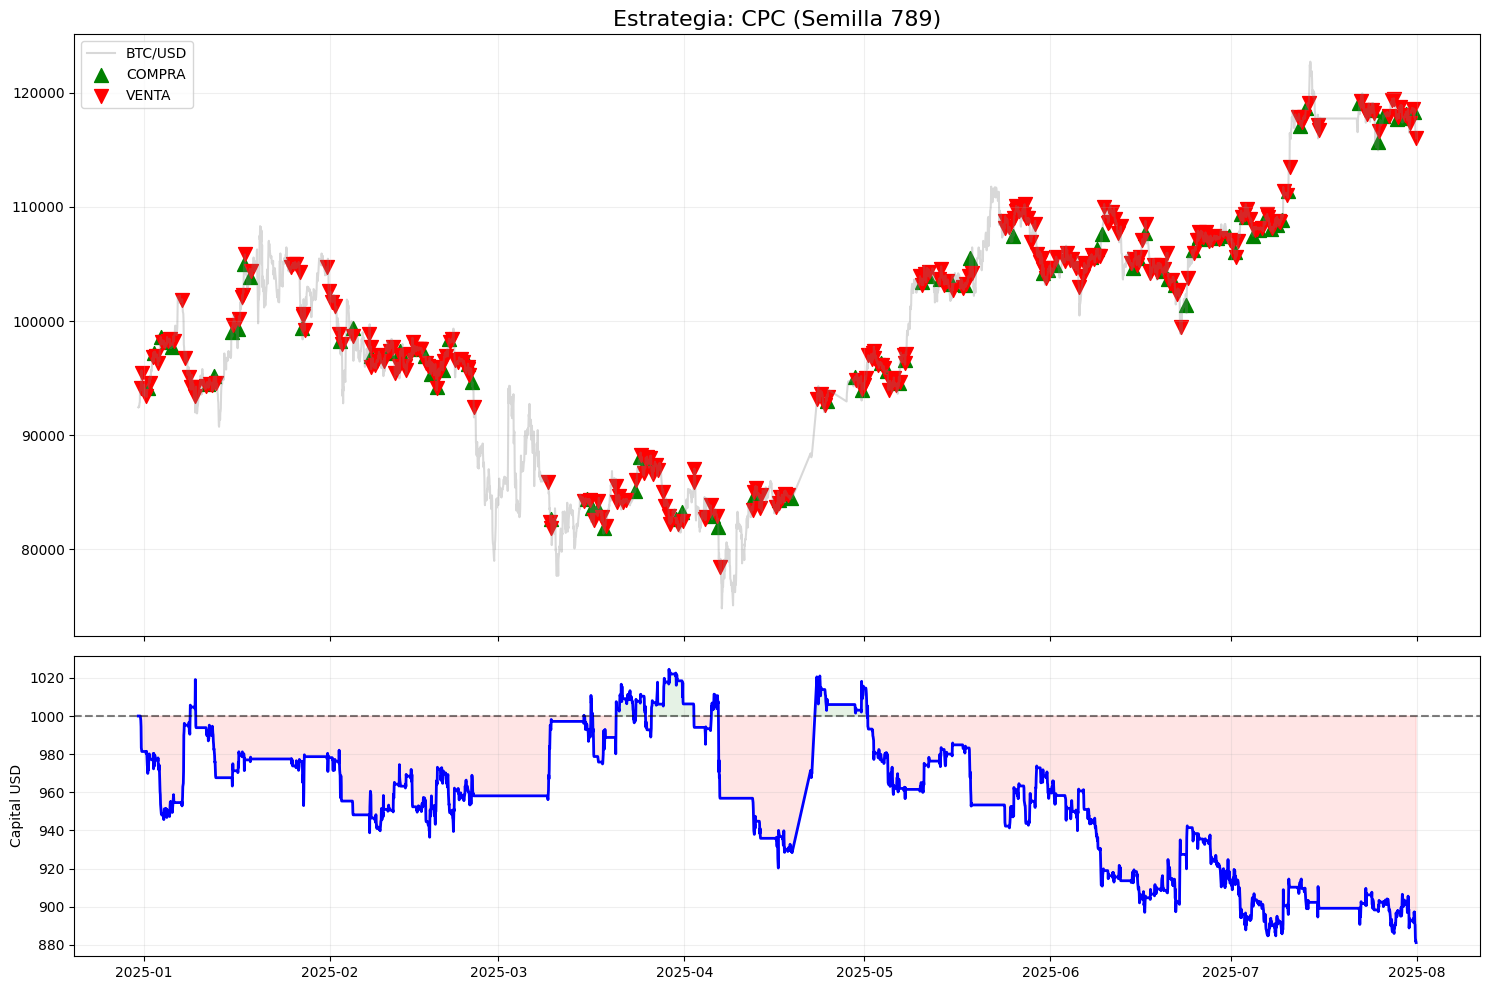


 ANALIZANDO MODELO: CPC | SEMILLA: 1011
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 79 | 🔴 Ventas: 91
📊 Total Operaciones: 170
🏁 Balance Final: $952.45 | 📈 Retorno: -4.76%
----------------------------------


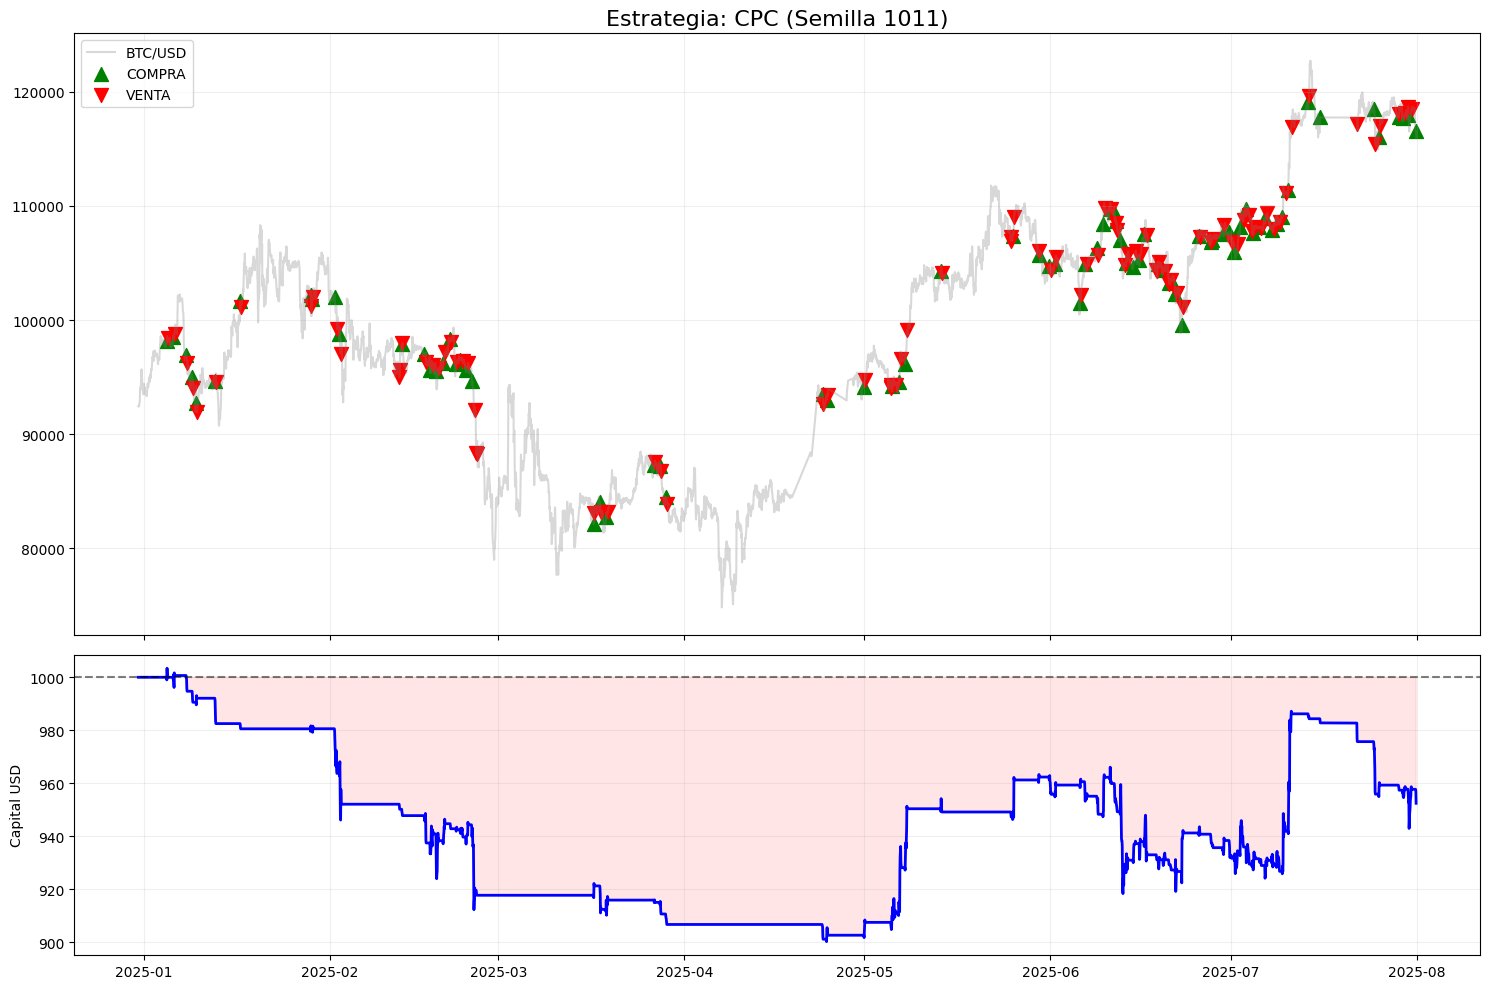


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 1 | 🔴 Ventas: 0
📊 Total Operaciones: 1
🏁 Balance Final: $1253.79 | 📈 Retorno: 25.38%
----------------------------------


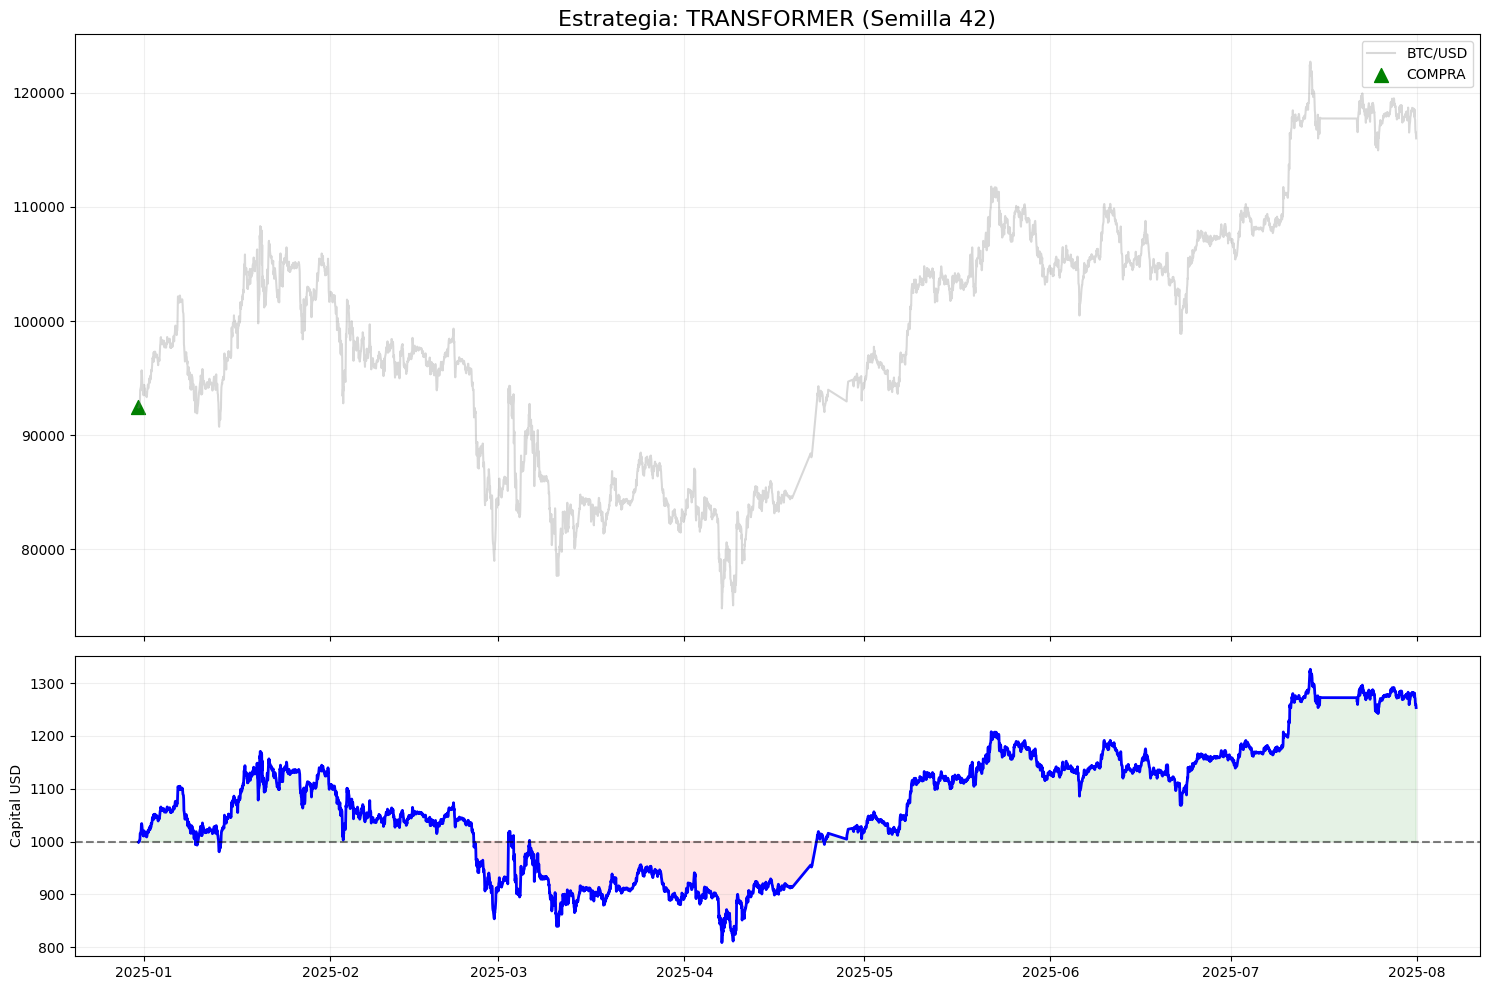


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


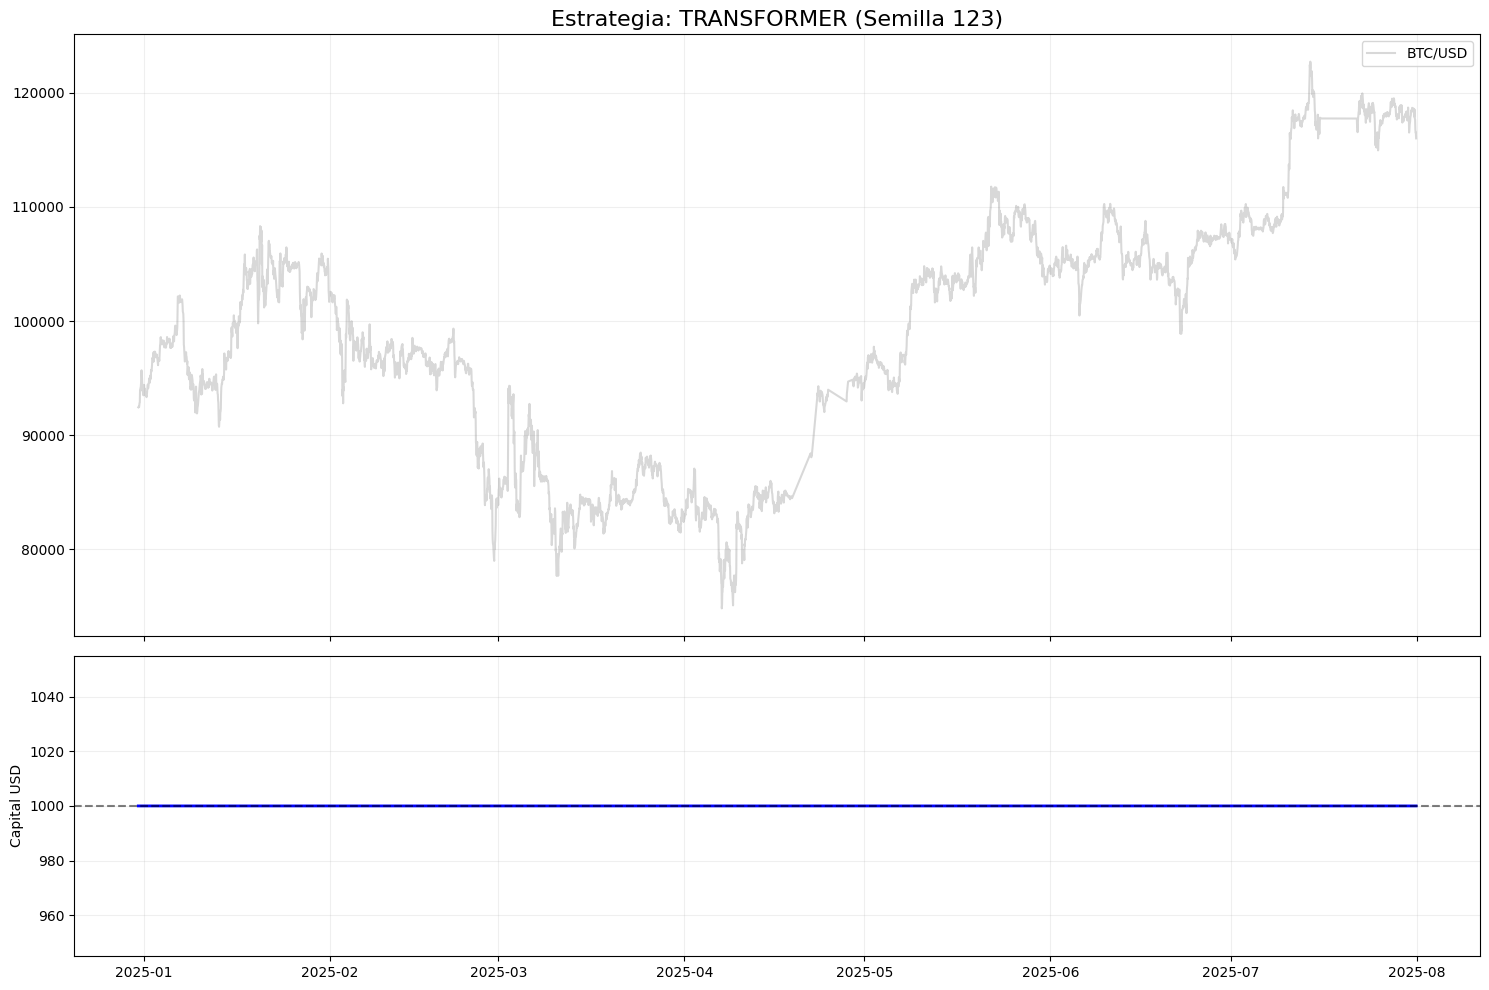


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


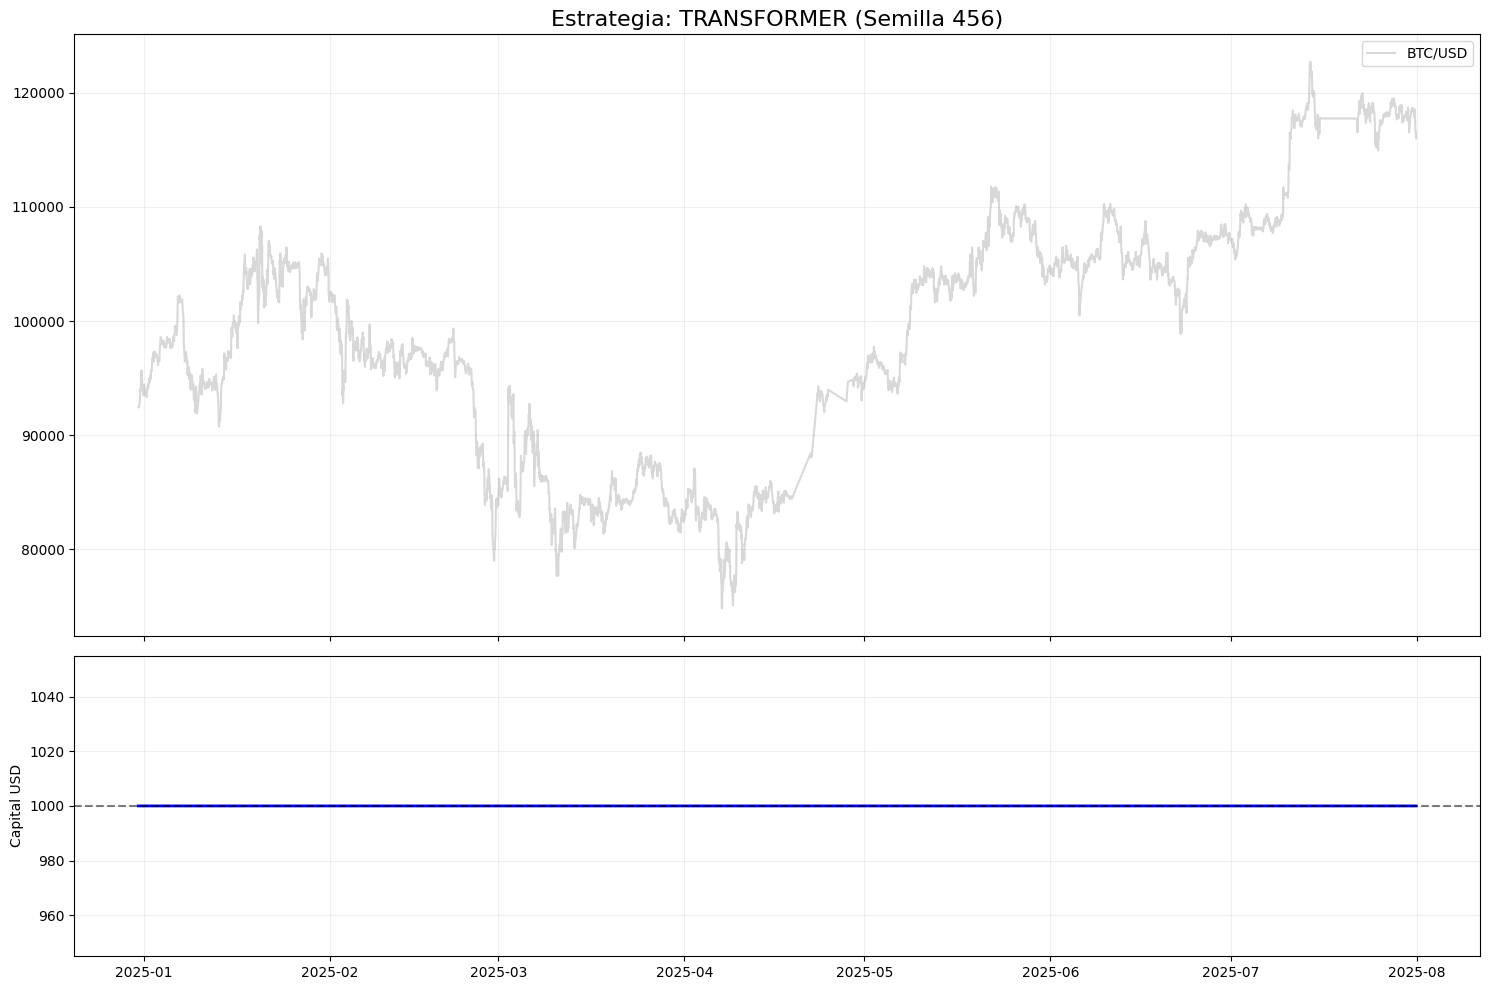


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 789
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------


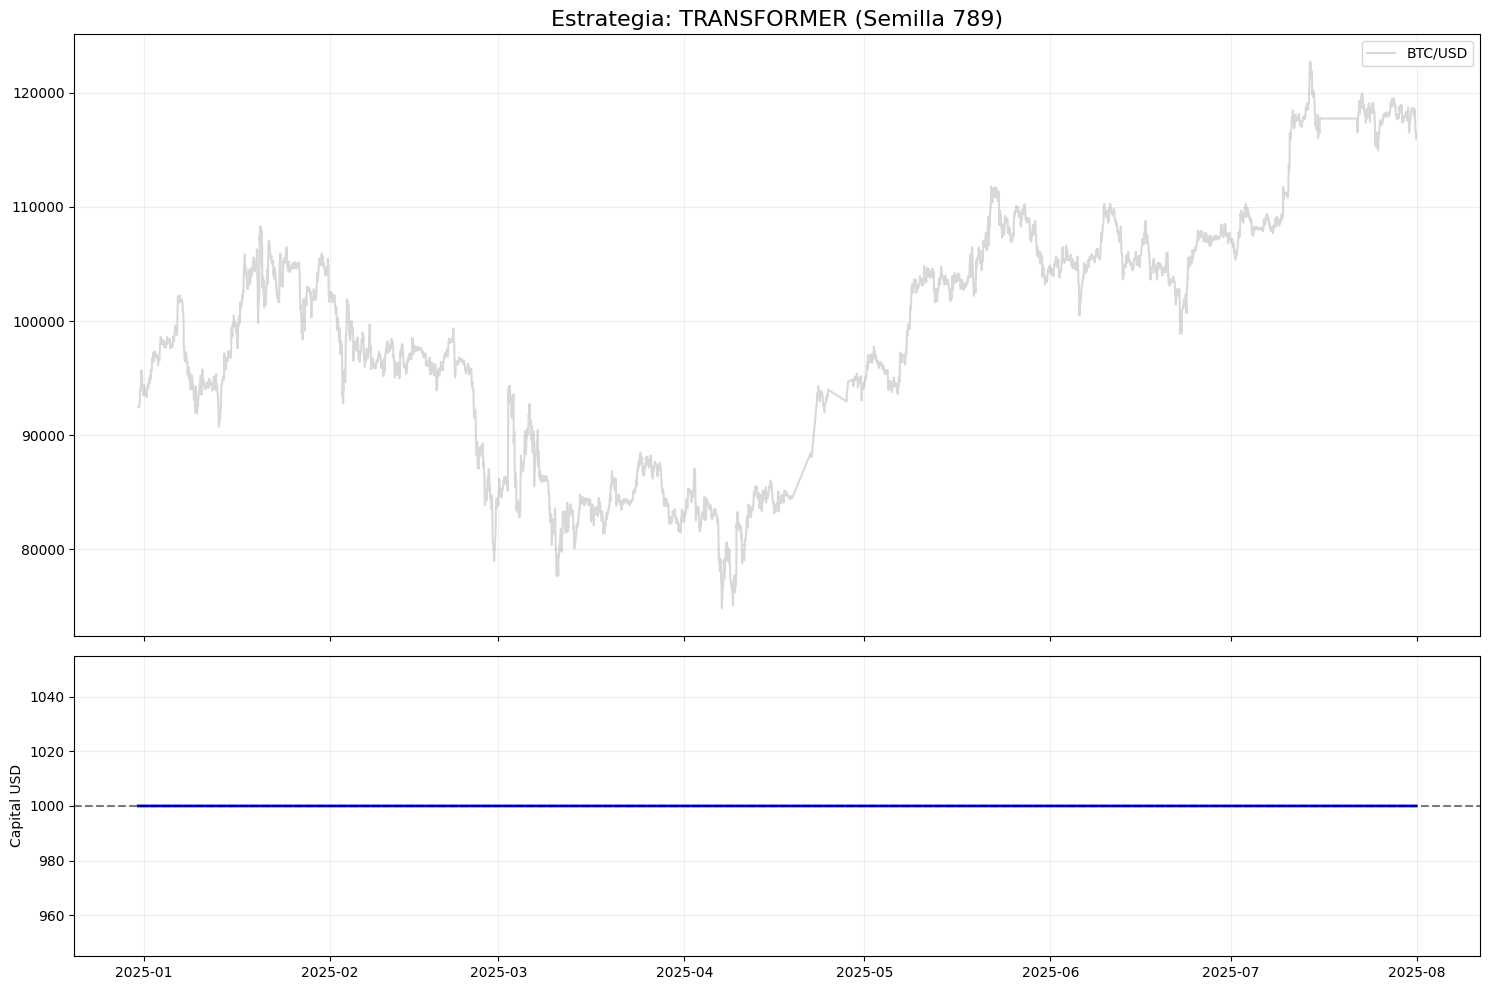


 ANALIZANDO MODELO: TRANSFORMER | SEMILLA: 1011
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 1 | 🔴 Ventas: 0
📊 Total Operaciones: 1
🏁 Balance Final: $1253.79 | 📈 Retorno: 25.38%
----------------------------------


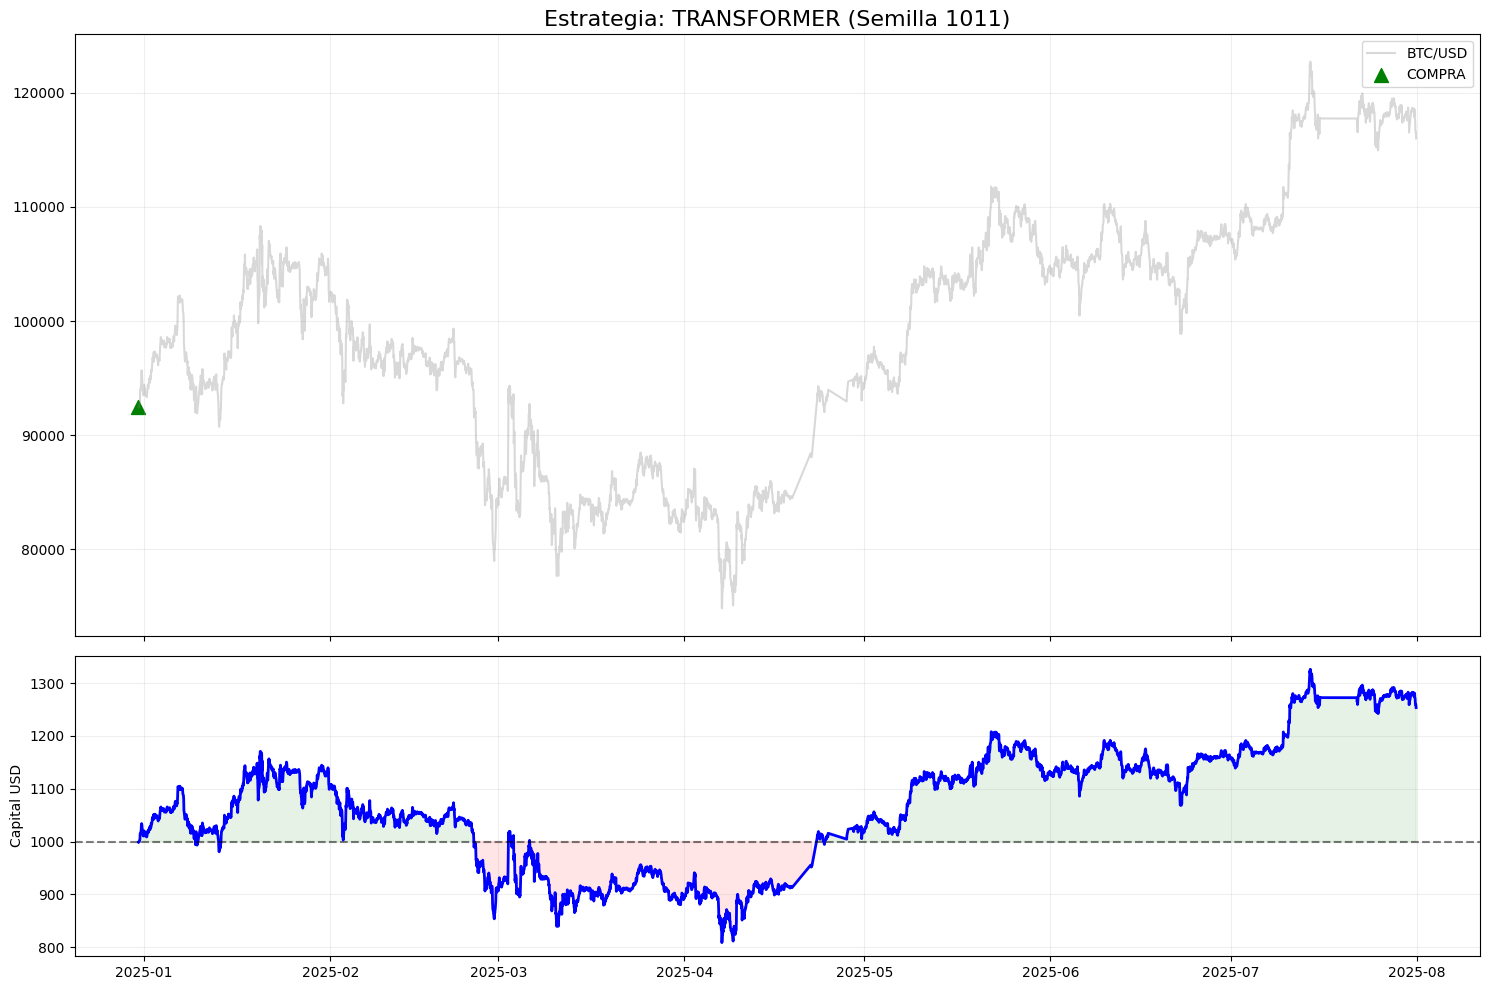


 ANALIZANDO MODELO: COMBINADO | SEMILLA: 42
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 199 | 🔴 Ventas: 201
📊 Total Operaciones: 400
🏁 Balance Final: $956.53 | 📈 Retorno: -4.35%
----------------------------------


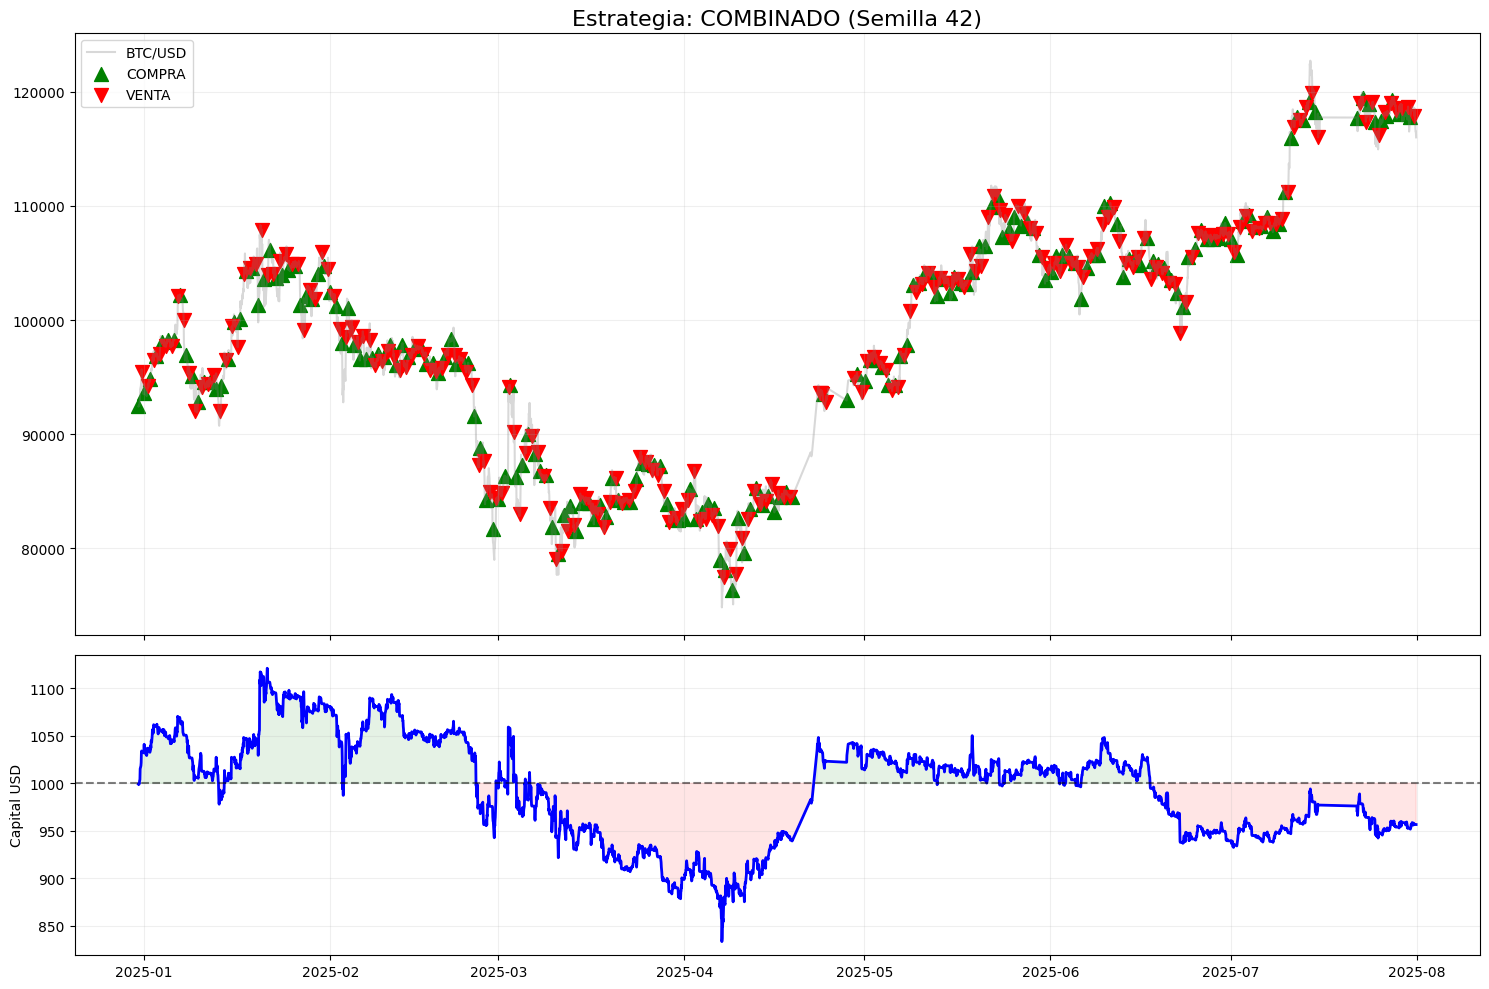


 ANALIZANDO MODELO: COMBINADO | SEMILLA: 123
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 1 | 🔴 Ventas: 5
📊 Total Operaciones: 6
🏁 Balance Final: $996.56 | 📈 Retorno: -0.34%
----------------------------------


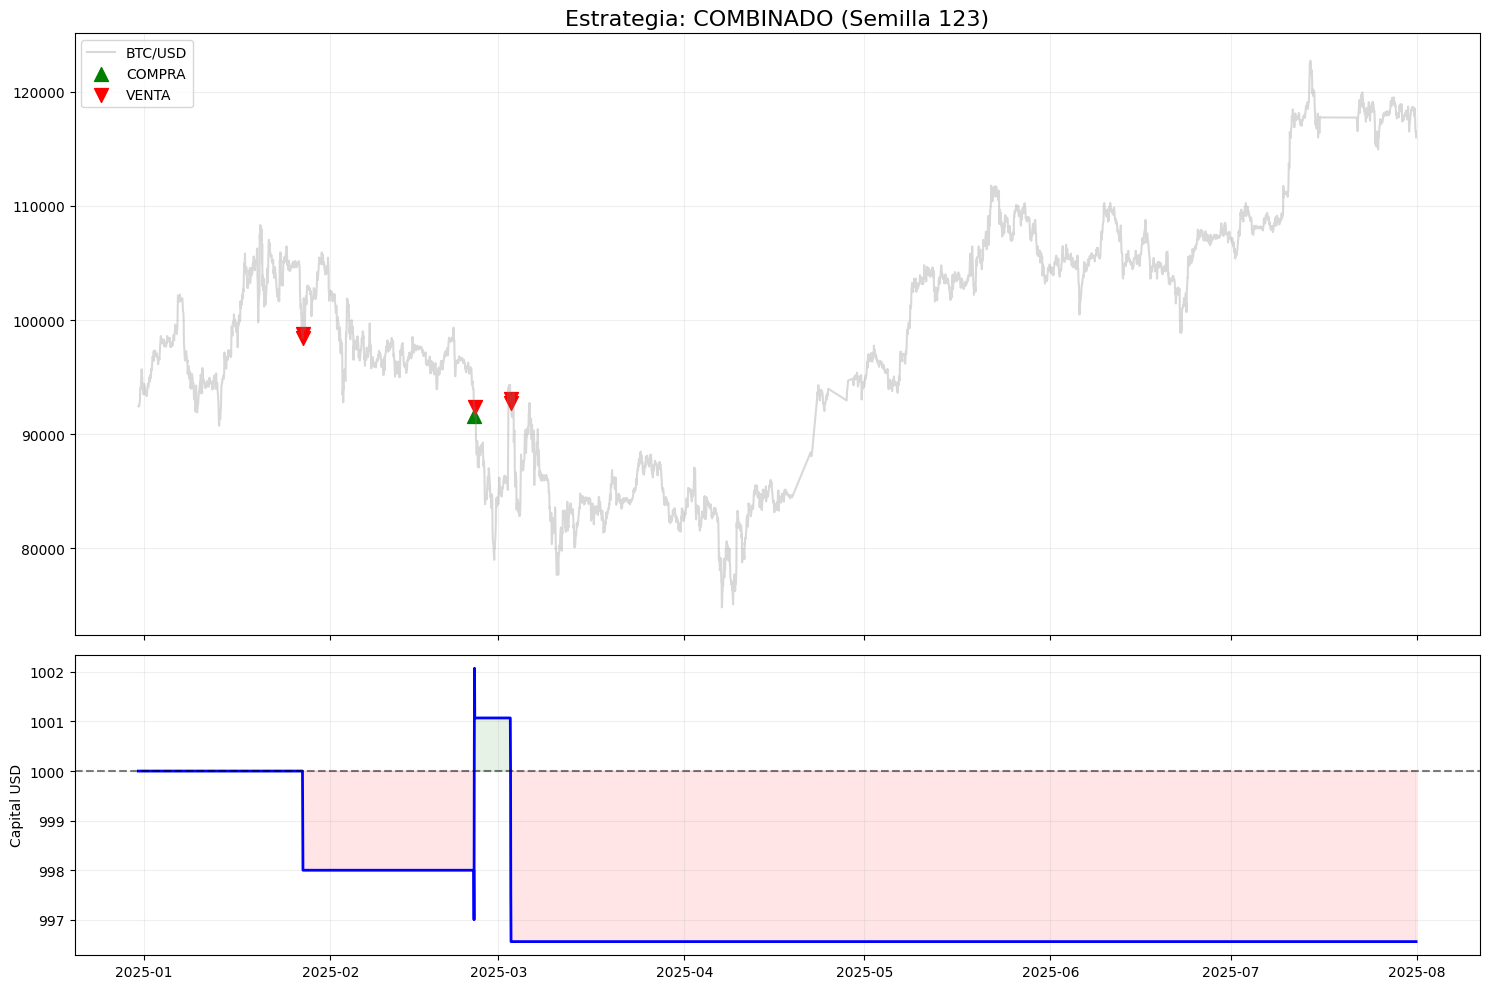


 ANALIZANDO MODELO: COMBINADO | SEMILLA: 456
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 15 | 🔴 Ventas: 15
📊 Total Operaciones: 30
🏁 Balance Final: $1014.91 | 📈 Retorno: 1.49%
----------------------------------


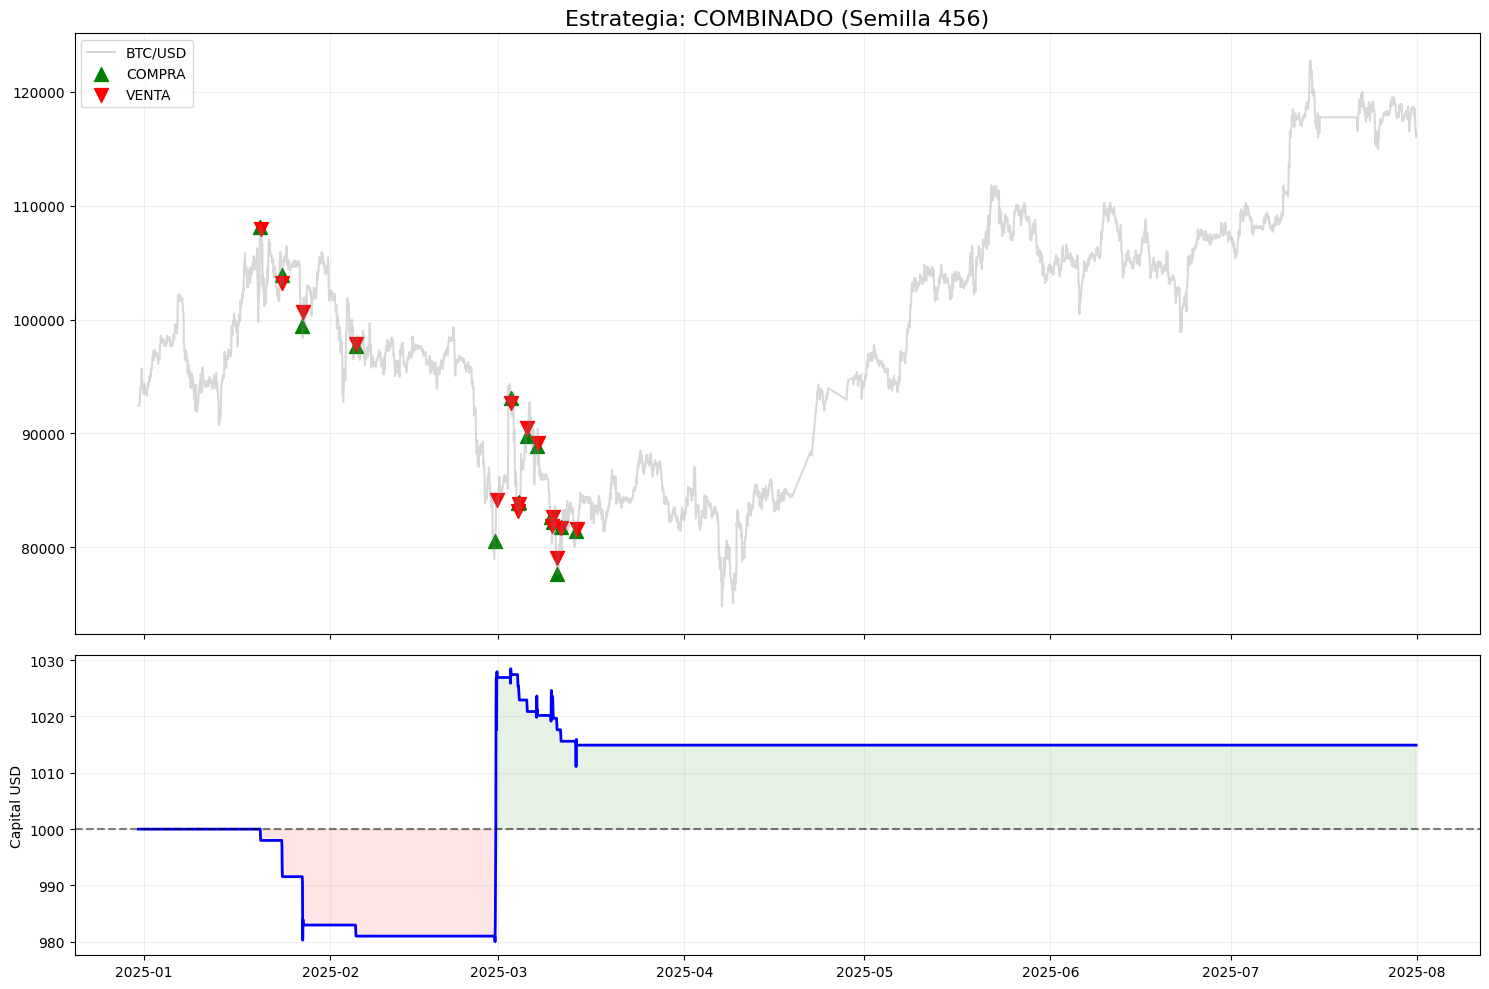


 ANALIZANDO MODELO: COMBINADO | SEMILLA: 789
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 32
📊 Total Operaciones: 32
🏁 Balance Final: $974.53 | 📈 Retorno: -2.55%
----------------------------------


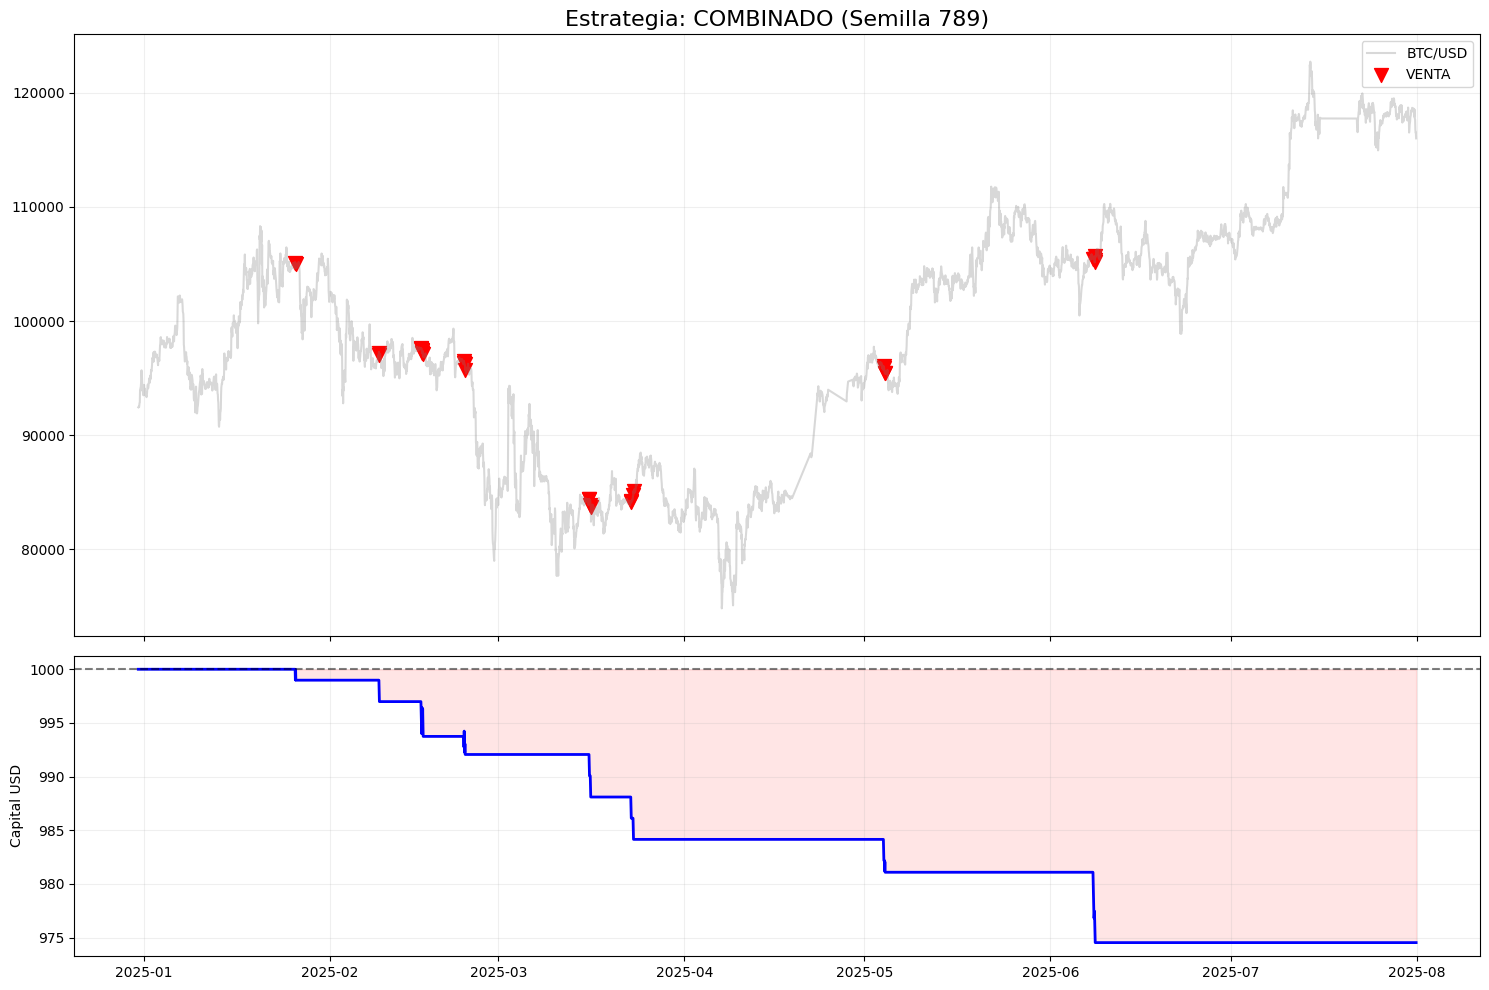


 ANALIZANDO MODELO: COMBINADO | SEMILLA: 1011
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 149 | 🔴 Ventas: 155
📊 Total Operaciones: 304
🏁 Balance Final: $1165.84 | 📈 Retorno: 16.58%
----------------------------------


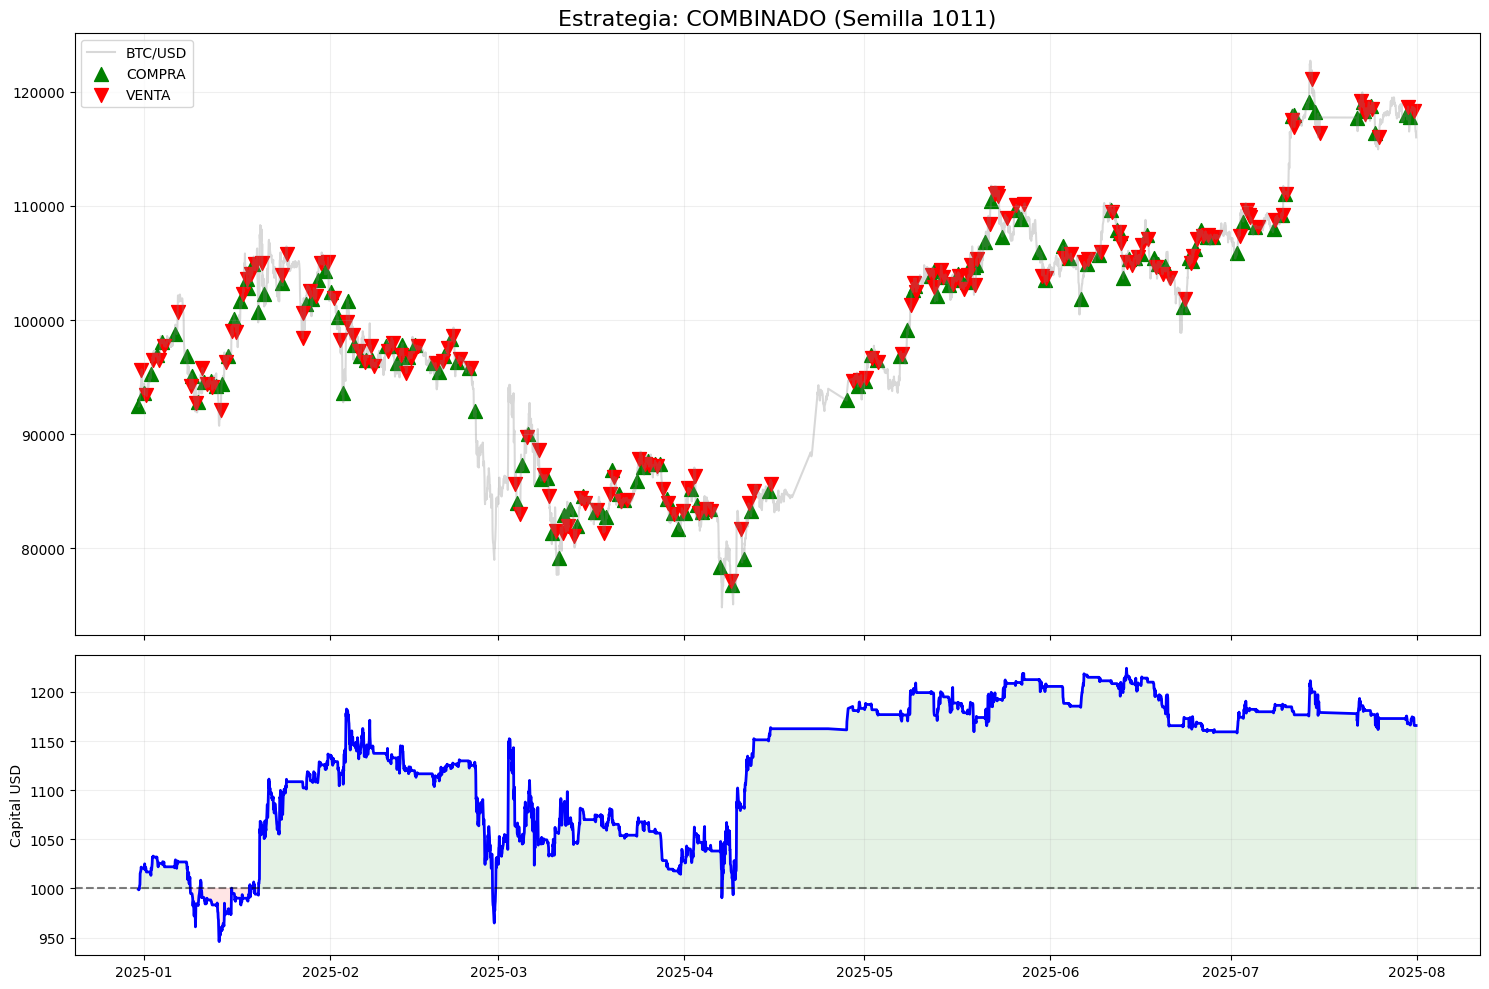

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from stable_baselines3 import DQN
from sklearn.preprocessing import MinMaxScaler

def plot_trading_results(model_name, seed, tf="1h"):
    print(f"\n" + "="*50)
    print(f" ANALIZANDO MODELO: {model_name.upper()} | SEMILLA: {seed}")
    print("="*50)

    # 1. Cargar datos específicos
    try:
        features_all, prices_all = load_data_all_types(model_name, tf)
        
        ### NUEVO: ESCALADO PARA EL BASELINE (IGUAL QUE EN EL ENTRENAMIENTO) ###
        if model_name == 'baseline':
            scaler = MinMaxScaler()
            # Ajustamos el escalador solo con la parte de entrenamiento para no hacer trampa (leakage)
            train_mask = features_all.index <= TRAIN_END_DATE
            scaler.fit(features_all[train_mask])
            
            # Transformamos todo el dataset de features
            features_scaled = scaler.transform(features_all)
            features_all = pd.DataFrame(features_scaled, index=features_all.index, columns=features_all.columns)
            print(f"⚠️ Features de Baseline escaladas correctamente.")
        ######################################################################

        val_size = 4698 
        df_feat_val = features_all.tail(val_size)
        df_prices_val = prices_all.tail(val_size)
        print(f"✅ Datos cargados: {len(df_feat_val)} velas para test.")
    except Exception as e:
        print(f"❌ Error al cargar datos: {e}")
        return

    # 2. Cargar el Agente
    model_path = f"../RL_outputs/models/ppo_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = PPO.load(model_path)

    # 3. Simulación sincronizada
    init_bal = 1000
    fee_rate = 0.001
    
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=init_bal, fee=fee_rate)
    
    obs, _ = env.reset()
    done = False
    net_worths = []
    actions = []
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        net_worths.append(info.get('net_worth', init_bal)) 
        actions.append(action)

    # 4. Detección de operaciones reales
    buys_idx = []
    sells_idx = []
    current_position = 0 
    
    last_pos = 1 # Empieza en Out
    for i, act in enumerate(actions):
        if act != last_pos:
            if act == 2: buys_idx.append(i) # Entrada en Long
            if act == 0: sells_idx.append(i) # Entrada en Short
            if act == 1: 
                # Aquí decides si lo marcas como venta o cierre
                sells_idx.append(i) 
        last_pos = act

    # 5. Estadísticas
    total_ops = len(buys_idx) + len(sells_idx)
    retorno_final = ((net_worths[-1] / init_bal) - 1) * 100
    
    print(f"\n--- ESTADÍSTICAS DE OPERATIVA ---")
    print(f"🔵 Compras: {len(buys_idx)} | 🔴 Ventas: {len(sells_idx)}")
    print(f"📊 Total Operaciones: {total_ops}")
    print(f"🏁 Balance Final: ${net_worths[-1]:.2f} | 📈 Retorno: {retorno_final:.2f}%")
    print("-" * 34)


    # 6. Gráficas
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2, 1]})
    
    prices = df_prices_val.values[:len(net_worths)]
    dates = df_prices_val.index[:len(net_worths)]

    ax1.plot(dates, prices, color='gray', alpha=0.3, label='BTC/USD')
    if buys_idx:
        ax1.scatter(dates[buys_idx], prices[buys_idx], marker='^', color='green', s=100, label='COMPRA')
    if sells_idx:
        ax1.scatter(dates[sells_idx], prices[sells_idx], marker='v', color='red', s=100, label='VENTA')
    
    ax1.set_title(f"Estrategia: {model_name.upper()} (Semilla {seed})", fontsize=16)
    ax1.legend()
    ax1.grid(alpha=0.2)

    ax2.plot(dates, net_worths, color='blue', lw=2)
    ax2.axhline(y=init_bal, color='black', linestyle='--', alpha=0.5)
    
    nw_arr = np.array(net_worths)
    ax2.fill_between(dates, init_bal, nw_arr, where=(nw_arr >= init_bal), color='green', alpha=0.1)
    ax2.fill_between(dates, init_bal, nw_arr, where=(nw_arr < init_bal), color='red', alpha=0.1)
    
    ax2.set_ylabel("Capital USD")
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
# Lanza los que quieras comparar:

plot_trading_results('baseline', 42)
plot_trading_results('baseline', 123)
plot_trading_results('baseline', 456)
plot_trading_results('baseline', 789)
plot_trading_results('baseline', 1011)


plot_trading_results('temporal-ae', 42)
plot_trading_results('temporal-ae', 123)
plot_trading_results('temporal-ae', 456)
plot_trading_results('temporal-ae', 789)
plot_trading_results('temporal-ae', 1011)

plot_trading_results('cpc', 42)
plot_trading_results('cpc', 123)
plot_trading_results('cpc', 456)
plot_trading_results('cpc', 789)
plot_trading_results('cpc', 1011)

plot_trading_results('transformer', 42)
plot_trading_results('transformer', 123)
plot_trading_results('transformer', 456)
plot_trading_results('transformer', 789)
plot_trading_results('transformer', 1011)

plot_trading_results('combinado', 42)
plot_trading_results('combinado', 123)
plot_trading_results('combinado', 456)
plot_trading_results('combinado', 789)
plot_trading_results('combinado', 1011)

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pyparsing import actions
from stable_baselines3 import DQN
from sklearn.preprocessing import MinMaxScaler

def trading_results(model_name, seed, tf="1h"):
    print(f"\n" + "="*50)
    print(f" ANALIZANDO MODELO: {model_name.upper()} | SEMILLA: {seed}")
    print("="*50)

    # 1. Cargar datos específicos
    try:
        features_all, prices_all = load_data_all_types(model_name, tf)
        
        ### NUEVO: ESCALADO PARA EL BASELINE (IGUAL QUE EN EL ENTRENAMIENTO) ###
        if model_name == 'baseline':
            scaler = MinMaxScaler()
            # Ajustamos el escalador solo con la parte de entrenamiento para no hacer trampa (leakage)
            train_mask = features_all.index <= TRAIN_END_DATE
            scaler.fit(features_all[train_mask])
            
            # Transformamos todo el dataset de features
            features_scaled = scaler.transform(features_all)
            features_all = pd.DataFrame(features_scaled, index=features_all.index, columns=features_all.columns)
            print(f"⚠️ Features de Baseline escaladas correctamente.")
        ######################################################################

        val_size = 4698 
        df_feat_val = features_all.tail(val_size)
        df_prices_val = prices_all.tail(val_size)
        print(f"✅ Datos cargados: {len(df_feat_val)} velas para test.")
    except Exception as e:
        print(f"❌ Error al cargar datos: {e}")
        return

    # 2. Cargar el Agente
    model_path = f"../RL_outputs/models/ppo_{model_name}_seed_{seed}.zip"
    if not os.path.exists(model_path):
        print(f"❌ No se encuentra el archivo: {model_path}")
        return
    
    agent = PPO.load(model_path)

    # 3. Simulación sincronizada
    init_bal = 1000
    fee_rate = 0.001
    
    env = SRLTradingEnv_v2(df_feat_val, df_prices_val, initial_balance=init_bal, fee=fee_rate)
    
    obs, _ = env.reset()
    done = False
    net_worths = []
    actions = []
    
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        net_worths.append(info.get('net_worth', init_bal)) 
        actions.append(action)

    # 4. Detección de operaciones reales
    buys_idx = []
    sells_idx = []
    current_position = 0 
    
    # En tu función de plot/stats
    last_pos = 1 # Empieza en Out
    for i, act in enumerate(actions):
        if act != last_pos:
            if act == 2: buys_idx.append(i) # Entrada en Long
            if act == 0: sells_idx.append(i) # Entrada en Short
            if act == 1: 
                # Aquí decides si lo marcas como venta o cierre
                sells_idx.append(i) 
        last_pos = act

    # 5. Estadísticas
    total_ops = len(buys_idx) + len(sells_idx)
    retorno_final = ((net_worths[-1] / init_bal) - 1) * 100
    
    print(f"\n--- ESTADÍSTICAS DE OPERATIVA ---")
    print(f"🔵 Compras: {len(buys_idx)} | 🔴 Ventas: {len(sells_idx)}")
    print(f"📊 Total Operaciones: {total_ops}")
    print(f"🏁 Balance Final: ${net_worths[-1]:.2f} | 📈 Retorno: {retorno_final:.2f}%")
    print("-" * 34)

# --- EJECUCIÓN ---
# Ahora los resultados del baseline deberían coincidir con los del entrenamiento (-58%, etc.)
trading_results('baseline', 42)
trading_results('baseline', 123)
trading_results('baseline', 456)
trading_results('baseline', 789)
trading_results('baseline', 1011)

trading_results('temporal-ae', 42)
trading_results('temporal-ae', 123)
trading_results('temporal-ae', 456)
trading_results('temporal-ae', 789)
trading_results('temporal-ae', 1011)

trading_results('cpc', 42)
trading_results('cpc', 123)
trading_results('cpc', 456)
trading_results('cpc', 789)
trading_results('cpc', 1011)

trading_results('transformer', 42)
trading_results('transformer', 123)
trading_results('transformer', 456)
trading_results('transformer', 789)
trading_results('transformer', 1011)

trading_results('combinado', 42)
trading_results('combinado', 123)
trading_results('combinado', 456)
trading_results('combinado', 789)
trading_results('combinado', 1011)



 ANALIZANDO MODELO: BASELINE | SEMILLA: 42
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 123
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 456
⚠️ Features de Baseline escaladas correctamente.
✅ Datos cargados: 4698 velas para test.

--- ESTADÍSTICAS DE OPERATIVA ---
🔵 Compras: 0 | 🔴 Ventas: 0
📊 Total Operaciones: 0
🏁 Balance Final: $1000.00 | 📈 Retorno: 0.00%
----------------------------------

 ANALIZANDO MODELO: BASELINE | SEMILLA: 789
⚠️ Features de Baseline escaladas correctamente.
✅ Datos ca

In [14]:
import numpy as np
import pandas as pd

# Datos de las semillas
resultados_ppo = {
    "Baseline": [0.00, 0.00, 0.00, 0.00, 26.40],
    "Temporal-AE": [25.38, 25.38, 11.64, 0.00, 13.38],
    "CPC": [-3.11, 23.76, -0.29, -11.89, -4.76],
    "Transformer": [25.38, 0.00, 0.00, 0.00, 25.38],
    "Combinado": [-4.35, -0.34, 1.49, -2.55, 16.58]
}

def generar_informe_completo(data):
    # 1. Cálculo de métricas base
    rows = []
    for modelo, retornos in data.items():
        media = np.mean(retornos)
        std = np.std(retornos)
        consistencia = media / std if std != 0 else 0
        rows.append({
            "Modelo": modelo,
            "Media_Num": media,
            "Desviacion_Num": std,
            "Consistencia_Num": consistencia
        })
    
    df_base = pd.DataFrame(rows)

    # Función interna para formatear y limpiar para el print
    def preparar_tabla(df, col_sort, ascendente=False):
        temp = df.sort_values(by=col_sort, ascending=ascendente).copy()
        temp["Media (%)"] = temp["Media_Num"].map(lambda x: f"{x:.2f}%")
        temp["Desv. Std"] = temp["Desviacion_Num"].map(lambda x: f"{x:.2f}")
        temp["Consistencia"] = temp["Consistencia_Num"].map(lambda x: f"{x:.2f}")
        return temp[["Modelo", "Media (%)", "Desv. Std", "Consistencia"]]

    # 2. Generación de las 3 tablas
    print("\n" + "="*70)
    print("CLASIFICACIÓN POR RENTABILIDAD MEDIA (¿Quién gana más?)")
    print("="*70)
    # Media: Más es mejor (ascending=False)
    print(preparar_tabla(df_base, "Media_Num", False).to_string(index=False))

    print("\n" + "="*70)
    print("CLASIFICACIÓN POR ESTABILIDAD / DESVIACIÓN (¿Quién es menos volátil?)")
    print("="*70)
    # Desviación: Menos es mejor (ascending=True)
    print(preparar_tabla(df_base, "Desviacion_Num", True).to_string(index=False))

    print("\n" + "="*70)
    print("CLASIFICACIÓN POR CONSISTENCIA (Ratio Media/Riesgo)")
    print("="*70)
    # Consistencia: Más es mejor (ascending=False)
    print(preparar_tabla(df_base, "Consistencia_Num", False).to_string(index=False))

# Ejecutar el análisis
generar_informe_completo(resultados_ppo)


CLASIFICACIÓN POR RENTABILIDAD MEDIA (¿Quién gana más?)
     Modelo Media (%) Desv. Std Consistencia
Temporal-AE    15.16%      9.53         1.59
Transformer    10.15%     12.43         0.82
   Baseline     5.28%     10.56         0.50
  Combinado     2.17%      7.47         0.29
        CPC     0.74%     12.13         0.06

CLASIFICACIÓN POR ESTABILIDAD / DESVIACIÓN (¿Quién es menos volátil?)
     Modelo Media (%) Desv. Std Consistencia
  Combinado     2.17%      7.47         0.29
Temporal-AE    15.16%      9.53         1.59
   Baseline     5.28%     10.56         0.50
        CPC     0.74%     12.13         0.06
Transformer    10.15%     12.43         0.82

CLASIFICACIÓN POR CONSISTENCIA (Ratio Media/Riesgo)
     Modelo Media (%) Desv. Std Consistencia
Temporal-AE    15.16%      9.53         1.59
Transformer    10.15%     12.43         0.82
   Baseline     5.28%     10.56         0.50
  Combinado     2.17%      7.47         0.29
        CPC     0.74%     12.13         0.06
